# Mathematical foundations of hedging under rough volatility

An independent technical study. Six sections build the objects used in the later notebooks: the conventions of the rough Bergomi model, the hybrid simulation scheme, the roughness estimator, Monte Carlo price estimators, the self-financing hedging identity, and risk measures. Each section states a claim with its provenance, derives what is needed, checks identities by simulation against a standard error computed in the same cell, and shows three figures: before the method, the method working, and the comparison with an exact oracle or the cited source.


> **Scope.** This is a synthetic-data research study, not production code, not evidence of live performance. Every number below comes from simulated paths produced by the package `rough_hedge`; statements attributed to a paper carry a `source:` tag and a short quotation, everything else is labelled `derived here` or measured here.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import io
import math
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy import integrate, stats

# fixed colour-blind-safe palette (Okabe-Ito) used by every figure
PAL = {'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73', 'vermillion': '#D55E00',
       'sky': '#56B4E9', 'purple': '#CC79A7', 'yellow': '#F0E442', 'grey': '#6B6B6B', 'black': '#222222'}
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10, 'axes.titlesize': 11, 'legend.frameon': False})

SEED = 20261002          # base seed; every cell derives its generator as np.random.default_rng(SEED + offset)
XI = 0.235 ** 2          # flat forward variance (variance units, not volatility)


def CHECK(label, passed, observed, expected):
    """Print one verdict line: CHECK <id>: <what> | observed=<number> | expected=<rule> | PASS or FAIL."""
    print(f"CHECK {label} | observed={float(observed):.4g} | expected={expected} | {'PASS' if bool(passed) else 'FAIL'}")


def show_fig(fig):
    """Render a matplotlib figure as an inline PNG output and release it."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    display(Image(data=buf.getvalue(), format='png'))


def _show_open_figures(*args, **kwargs):
    """plt.show replacement: emit one inline PNG per open figure, then close it (no figure is shown twice)."""
    for num in list(plt.get_fignums()):
        show_fig(plt.figure(num))


plt.show = _show_open_figures


# 1. Conventions

**Claim.** source: rhA-q8 (sec 1, the McCrickerd and Pakkanen row; the same equations are Eq 1.2 of rhA-q4-1708.02563). With $a=H-\tfrac12\in(-\tfrac12,0)$ the normalised Volterra process $\tilde W_t=\sqrt{2H}\int_0^t (t-u)^a\,dW_u$ has variance $t^{2H}$, hence $V_t=\xi_0\exp\!\big(\eta\tilde W_t-\tfrac{\eta^2}{2}t^{2H}\big)$ has constant mean $\xi_0$, the flat forward variance. In this notebook the vol-of-vol is $\eta=\nu$: the conversion between $\eta$ and $\nu$ printed in rhA-q8 is not adopted, because its own quoted definitions contradict it (see the derivation below). Package convention (header of the simulator module): zero rate, $S_0=1$, time in years, $\tilde W$ on the grid $t_i=iT/n$.

> $W_\alpha t := \sqrt{2\alpha+1}\int_0^t (t-u)^\alpha dW^1_u$ for $\alpha\in(-1/2,0)$ and $V_t=\xi_0(t)\exp\left(\eta W_\alpha t-\frac{\eta^2}{2}t^{2\alpha+1}\right)$ (rhA-q8, sec 1)

> $\xi_0(t)=\mathbb{E}[V_t]$ is the forward variance curve (rhA-q4-1708.02563, sec 1)

> $\mathrm{Var}\left[\int_0^t (t-s)^\alpha dW_s\right]=\frac{t^{2\alpha+1}}{2\alpha+1}$ (rhA-q8, sec 1, item 3)

> printed conversion, not adopted: $\eta=\sqrt{2H}\,\nu=\sqrt{2\alpha+1}\,\nu$ (rhA-q8, sec 1, item 2)

**Derivation of the variance law** (derived here).

1. A Wiener integral of a deterministic kernel is centred Gaussian, $\int_0^t f\,dW\sim N\big(0,\int_0^t f^2du\big)$ (Itô isometry), provided $f\in L^2(0,t)$. For $f(u)=(t-u)^a$ the square $(t-u)^{2a}$ is integrable at $u=t$ exactly when $2a>-1$, that is $H>0$; this is why the model lives on $H\in(0,\tfrac12)$.
2. Substituting $v=t-u$ gives $\int_0^t (t-u)^{2a}du=\int_0^t v^{2a}dv=\dfrac{t^{2a+1}}{2a+1}=\dfrac{t^{2H}}{2H}$.
3. Therefore $\operatorname{Var}\tilde W_t=2H\cdot\dfrac{t^{2H}}{2H}=t^{2H}$: the factor $\sqrt{2H}$ is exactly the constant that turns the variance into a pure power of $t$.
4. For $s\le t$ the same isometry gives $\operatorname{Cov}(\tilde W_s,\tilde W_t)=2H\int_0^s (s-u)^a(t-u)^a\,du$. The process is Gaussian and centred with non-stationary increments; this covariance is the exact reference used in the next section.

**Derivation of the mean and the second moment** (derived here).

5. For a Gaussian $X\sim N(0,\sigma^2)$ the moment generating function is $\mathbb{E}e^{\eta X}=e^{\eta^2\sigma^2/2}$; with $\sigma^2=t^{2H}$ from step 3, $\mathbb{E}e^{\eta\tilde W_t}=\exp\!\big(\tfrac{\eta^2}{2}t^{2H}\big)$.
6. Hence $\mathbb{E}V_t=\xi_0\,e^{-\frac{\eta^2}{2}t^{2H}}\,e^{\frac{\eta^2}{2}t^{2H}}=\xi_0$. The term $-\tfrac{\eta^2}{2}t^{2H}$ is the compensator that makes the mean constant in $t$, which matches the quoted definition $\xi_0(t)=\mathbb{E}[V_t]$ for a flat curve.
7. The second moment is lognormal, $\operatorname{Var}V_t=\xi_0^2\big(e^{\eta^2t^{2H}}-1\big)$. For small $H$ the factor $t^{2H}$ stays close to one even for very short $t$, so the dispersion of $V_t$ does not collapse quickly as $t\downarrow0$ (it is exactly zero only at $t=0$).

**Derivation of $\eta=\nu$** (derived here).

8. The exponent in the stochastic-exponential form is $M_t=\sqrt{2H}\,\nu\int_0^t(t-s)^a\,dZ_s$. By steps 2 and 3, $\operatorname{Var}M_t=2H\nu^2\cdot\dfrac{t^{2H}}{2H}=\nu^2t^{2H}$. The exponent of the Volterra form is $\eta\tilde W_t$ with variance $\eta^2t^{2H}$. The two models have the same law of $V$ exactly when $\eta^2=\nu^2$, so $\eta=\nu$. The printed conversion $\eta=\sqrt{2H}\,\nu$ would double count the factor $\sqrt{2H}$, because $\tilde W$ already contains it; the variances would differ by the factor $2H$ (printed by the CHECK cell below as an information line). The trace calls $\operatorname{Var}M_t$ a quadratic variation; for a Gaussian value at a fixed $t$ it is the variance, which is the quantity that enters the compensator.
9. Spot and variance: $V_t=\sigma_t^2$ (rhA-q8, item 4), and the price solves $dS_t=S_t\sqrt{V_t}\,(\rho\,dW_t+\sqrt{1-\rho^2}\,dW'_t)$ with zero rate and $S_0=1$ (package convention).

In [2]:
from rough_hedge.rbergomi import simulate_volterra, simulate_rbergomi

# CONV-1: Var(W~_t) / t^(2H) = 1 at grid times, tolerance from the relative standard error of a Gaussian sample variance
H1, N1, n1, T1 = 0.1, 200000, 16, 1.0
W1 = simulate_volterra(N1, n1, T1, H1, kappa=1, rng=np.random.default_rng(SEED + 11))
cols = [4, 8, 16]
ratio1 = W1.var(axis=0, ddof=1)[cols] / (np.array(cols) * T1 / n1) ** (2 * H1)
z1 = np.abs(ratio1 - 1.0) / math.sqrt(2.0 / (N1 - 1))
CHECK('CONV-1: variance of the Volterra driver equals t^(2H)', z1.max() <= 4.5, z1.max(),
      'max |z| over three grid times <= 4.5, SE = sqrt(2/(N-1))')
del W1

# CONV-2: the mean of V at the last grid time equals the flat forward variance
N2 = 200000
V2 = simulate_rbergomi(N2, 16, 0.25, 0.1, eta=1.0, rho=-0.7, xi0=XI, rng=np.random.default_rng(SEED + 12))['V'][:, -1]
z2 = abs(V2.mean() - XI) / (V2.std(ddof=1) / math.sqrt(N2))
CHECK('CONV-2: mean of V_T equals xi0', z2 <= 4.0, z2, '|z| <= 4, SE = std/sqrt(N)')
del V2

# CONV-3: Var(sqrt(2H) * int (t-u)^a dW) = t^(2H) via an independent numerical integral; eta = nu
H3, T3, nu3 = 0.1, 0.5, 1.9
a3 = H3 - 0.5
I3, I3_err = integrate.quad(lambda v: 1.0, 0.0, T3, weight='alg', wvar=(2 * a3, 0.0))   # int_0^T v^(2a) dv
dev3 = abs(2 * H3 * nu3 ** 2 * I3 - nu3 ** 2 * T3 ** (2 * H3))
tol3 = 10 * 2 * H3 * nu3 ** 2 * I3_err + 1e-12
CHECK('CONV-3: variance of the exponent equals eta^2 t^(2H) when eta = nu', dev3 <= tol3, dev3,
      f'|2H nu^2 I - nu^2 T^(2H)| <= 10 x quad error + 1e-12 = {tol3:.3g}')
wrong_ratio = (math.sqrt(2 * H3) * nu3) ** 2 / nu3 ** 2
print(f"info: variance of the exponent with eta = sqrt(2H) nu, relative to eta = nu: {wrong_ratio:.4f} (equals 2H = {2 * H3:.4f})")

# CONV-4: the scheme excludes H = 1/2 (a = 0) and kappa outside {0, 1}
raised = 0
for kw in (dict(H=0.5, kappa=1), dict(H=0.1, kappa=2)):
    try:
        simulate_volterra(10, 4, 1.0, kw['H'], kappa=kw['kappa'], rng=np.random.default_rng(SEED + 14))
    except ValueError:
        raised += 1
CHECK('CONV-4: H = 1/2 and kappa = 2 are rejected', raised == 2, raised, 'number of ValueError raised = 2')

CHECK CONV-1: variance of the Volterra driver equals t^(2H) | observed=1.651 | expected=max |z| over three grid times <= 4.5, SE = sqrt(2/(N-1)) | PASS


CHECK CONV-2: mean of V_T equals xi0 | observed=1.463 | expected=|z| <= 4, SE = std/sqrt(N) | PASS
CHECK CONV-3: variance of the exponent equals eta^2 t^(2H) when eta = nu | observed=4.441e-16 | expected=|2H nu^2 I - nu^2 T^(2H)| <= 10 x quad error + 1e-12 = 2.71e-12 | PASS
info: variance of the exponent with eta = sqrt(2H) nu, relative to eta = nu: 0.2000 (equals 2H = 0.2000)
CHECK CONV-4: H = 1/2 and kappa = 2 are rejected | observed=2 | expected=number of ValueError raised = 2 | PASS


**Pre-research figure:** what do rough Bergomi price and variance paths look like for several roughness values? Three values of $H$, the same seed, four sample paths each; the top row shows $V_t$, the bottom row $S_t$ (zero rate, $S_0=1$), with common vertical axes per row. No exact oracle exists yet; the figure states the problem before any estimator is built.

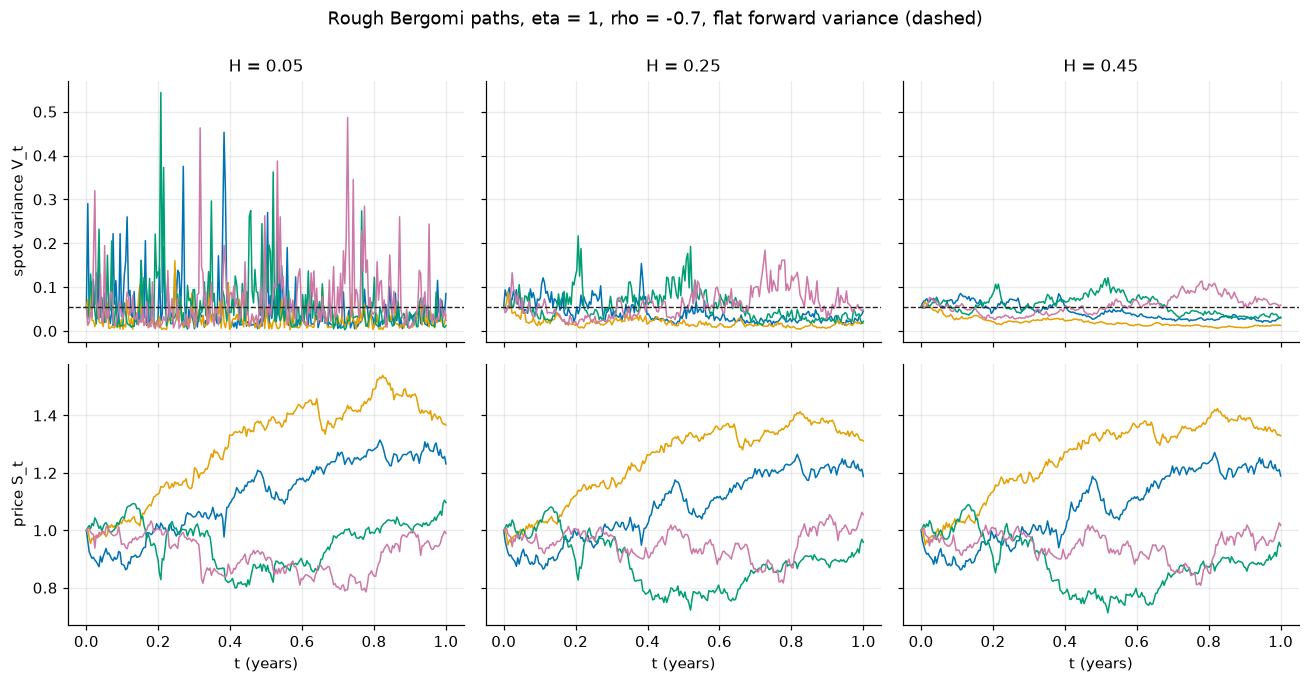

   H  mean |one-step change of log V|  median V at t=1 / xi0
0.05                            0.804                  0.595
0.25                            0.220                  0.584
0.45                            0.066                  0.593


In [3]:
Hs = [0.05, 0.25, 0.45]
tg = np.linspace(0.0, 1.0, 257)
fig, ax = plt.subplots(2, 3, figsize=(12, 6.2), sharex=True, sharey='row')
rows = []
for j, H in enumerate(Hs):
    out = simulate_rbergomi(4, 256, 1.0, H, eta=1.0, rho=-0.7, xi0=XI, rng=np.random.default_rng(SEED + 21))
    for p, colour in enumerate([PAL['blue'], PAL['orange'], PAL['green'], PAL['purple']]):
        ax[0, j].plot(tg, out['V'][p], color=colour, lw=1.0)
        ax[1, j].plot(tg, out['S'][p], color=colour, lw=1.0)
    ax[0, j].axhline(XI, color=PAL['black'], ls='--', lw=0.9)
    ax[0, j].set_title(f'H = {H}')
    ax[1, j].set_xlabel('t (years)')
    big = simulate_rbergomi(2000, 256, 1.0, H, eta=1.0, rho=-0.7, xi0=XI, rng=np.random.default_rng(SEED + 22))
    dlog = np.abs(np.diff(np.log(big['V']), axis=1))[:, 128:]
    rows.append({'H': H, 'mean |one-step change of log V|': dlog.mean(), 'median V at t=1 / xi0': np.median(big['V'][:, -1]) / XI})
ax[0, 0].set_ylabel('spot variance V_t')
ax[1, 0].set_ylabel('price S_t')
fig.suptitle('Rough Bergomi paths, eta = 1, rho = -0.7, flat forward variance (dashed)', y=0.995)
fig.tight_layout()
show_fig(fig)
print(pd.DataFrame(rows).round(3).to_string(index=False))

**How to read.** Each panel shows a few paths of one quantity for one roughness value, with the same random seed across columns. A smaller $H$ gives a visibly more jagged variance path, while the spot path keeps its overall shape. The dashed line is the flat forward variance. The table lists, for each $H$, the typical one-step change of $\log V$ late in the horizon: it is largest for the smallest $H$.

**Mid-research figure:** does the variance of the Volterra driver scale as $t^{2H}$, which is what the $\sqrt{2H}$ normalisation is meant to deliver? Left: the empirical $\operatorname{Var}\tilde W_t$ against $t$ on log-log axes with the dashed power law, one colour per $H$. Right: the ratio empirical over $t^{2H}$ with a band of two standard errors $\sqrt{2/(N-1)}$.

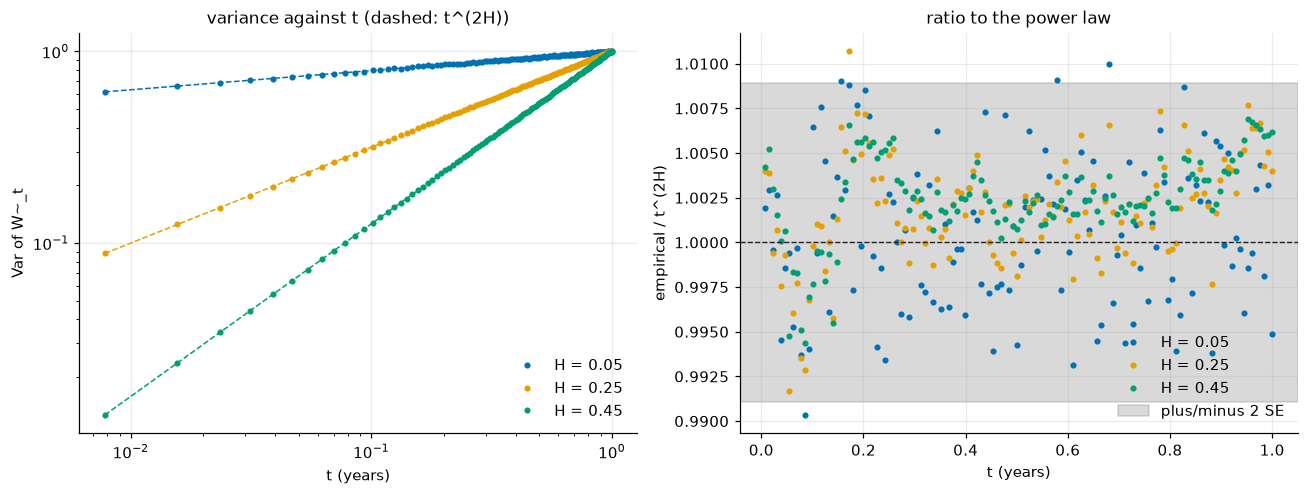

   H  fitted slope  2H  max |ratio - 1|  points outside 2 SE  ratio at first grid time
0.05        0.1002 0.1           0.0100                    4                    1.0019
0.25        0.5010 0.5           0.0107                    1                    1.0040
0.45        0.9009 0.9           0.0069                    0                    1.0042


In [4]:
Nm, nm = 100000, 128
tm = np.arange(1, nm + 1) / nm
se_rel = math.sqrt(2.0 / (Nm - 1))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
rows = []
for H, colour in zip(Hs, [PAL['blue'], PAL['orange'], PAL['green']]):
    Wm = simulate_volterra(Nm, nm, 1.0, H, kappa=1, rng=np.random.default_rng(SEED + 31))
    var_emp = Wm.var(axis=0, ddof=1)[1:]
    del Wm
    ax[0].loglog(tm, var_emp, 'o', ms=3, color=colour, label=f'H = {H}')
    ax[0].loglog(tm, tm ** (2 * H), '--', color=colour, lw=1)
    ratio = var_emp / tm ** (2 * H)
    ax[1].plot(tm, ratio, 'o', ms=3, color=colour, label=f'H = {H}')
    slope = np.polyfit(np.log(tm), np.log(var_emp), 1)[0]
    rows.append({'H': H, 'fitted slope': slope, '2H': 2 * H, 'max |ratio - 1|': np.abs(ratio - 1).max(),
                 'points outside 2 SE': int((np.abs(ratio - 1) > 2 * se_rel).sum()), 'ratio at first grid time': ratio[0]})
ax[1].axhspan(1 - 2 * se_rel, 1 + 2 * se_rel, color=PAL['grey'], alpha=0.25, label='plus/minus 2 SE')
ax[1].axhline(1.0, color=PAL['black'], ls='--', lw=0.9)
ax[0].set_xlabel('t (years)'); ax[0].set_ylabel('Var of W~_t'); ax[0].set_title('variance against t (dashed: t^(2H))')
ax[1].set_xlabel('t (years)'); ax[1].set_ylabel('empirical / t^(2H)'); ax[1].set_title('ratio to the power law')
ax[0].legend(); ax[1].legend()
fig.tight_layout()
show_fig(fig)
print(pd.DataFrame(rows).round(4).to_string(index=False))

**How to read.** Points on the dashed line mean the variance follows the pure power law; the three slopes on log-log axes are $2H$. The ratio panel isolates departures from it, and the grey band shows how much sampling noise to expect: with $N$ paths the relative standard error of a sample variance is $\sqrt{2/(N-1)}$. The first grid time is a useful probe because only the exactly sampled first cell contributes there.

**Post-research figure:** is the mean of the simulated variance equal to the flat forward variance $\xi_0$ at every time, as the quoted definition $\xi_0(t)=\mathbb{E}[V_t]$ requires? Left: the simulated mean $\bar V_t$ divided by $\xi_0$ with a band of plus/minus four standard errors, for two values of $\eta$, against the exact level one (Gaussian moment generating function, derivation step 6). Right: the standardised difference with horizontal lines at plus/minus four. CHECK CONV-2 above tests the last grid time of a shorter run.

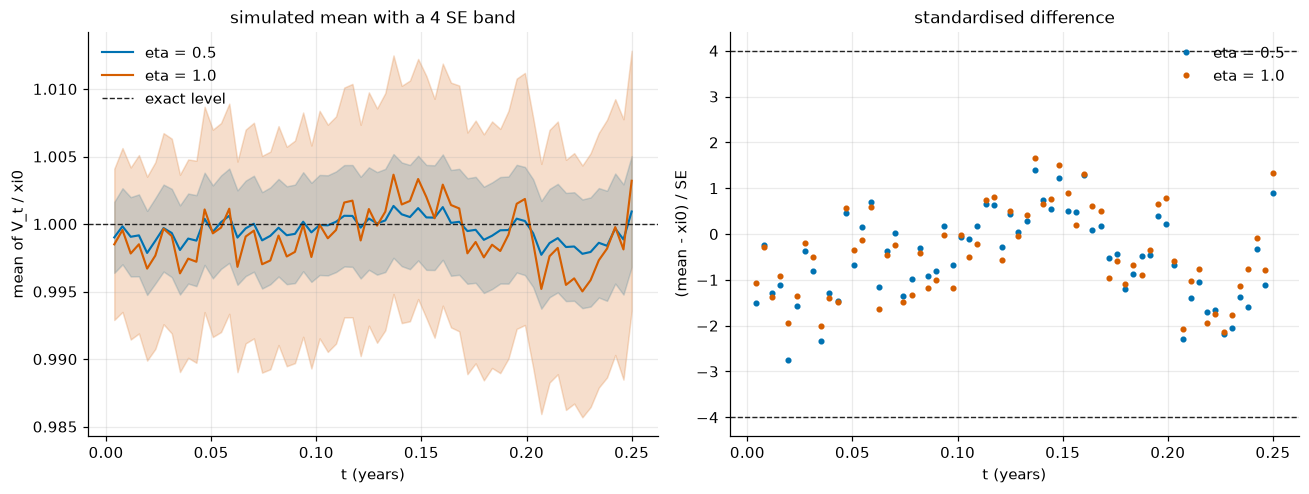

 eta  max |z|  mean z  half-width of the band / xi0
 0.5     2.75  -0.501                         0.004
 1.0     2.14  -0.440                         0.010


In [5]:
Np, np_steps, Tp = 200000, 64, 0.25
tp = np.arange(1, np_steps + 1) * Tp / np_steps
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
rows = []
for eta, colour in zip([0.5, 1.0], [PAL['blue'], PAL['vermillion']]):
    Vp = simulate_rbergomi(Np, np_steps, Tp, 0.1, eta=eta, rho=-0.7, xi0=XI, rng=np.random.default_rng(SEED + 41))['V'][:, 1:]
    mean_t = Vp.mean(axis=0)
    se_t = Vp.std(axis=0, ddof=1) / math.sqrt(Np)
    del Vp
    zt = (mean_t - XI) / se_t
    ax[0].plot(tp, mean_t / XI, color=colour, lw=1.4, label=f'eta = {eta}')
    ax[0].fill_between(tp, (mean_t - 4 * se_t) / XI, (mean_t + 4 * se_t) / XI, color=colour, alpha=0.2)
    ax[1].plot(tp, zt, 'o', ms=3, color=colour, label=f'eta = {eta}')
    rows.append({'eta': eta, 'max |z|': np.abs(zt).max(), 'mean z': zt.mean(), 'half-width of the band / xi0': 4 * se_t[-1] / XI})
ax[0].axhline(1.0, color=PAL['black'], ls='--', lw=0.9, label='exact level')
for s in (-4, 4):
    ax[1].axhline(s, color=PAL['black'], ls='--', lw=0.9)
ax[0].set_xlabel('t (years)'); ax[0].set_ylabel('mean of V_t / xi0'); ax[0].set_title('simulated mean with a 4 SE band')
ax[1].set_xlabel('t (years)'); ax[1].set_ylabel('(mean - xi0) / SE'); ax[1].set_title('standardised difference')
ax[0].legend(); ax[1].legend()
fig.tight_layout()
show_fig(fig)
print(pd.DataFrame(rows).round(3).to_string(index=False))

**How to read.** The solid line is the simulated mean with its band, the dashed line the exact flat level. Agreement means the band covers the dashed line at every time; a larger $\eta$ only widens the band. In the right panel the points should stay between the two dashed lines and show no trend in $t$.

**Interpretation.** Roughness is visible by eye and enters the variance only through the exponent: the three fitted slopes of $\operatorname{Var}\tilde W_t$ on log-log axes agree with $2H$ to the printed precision, and the ratio to the power law stays within about one percent, with at most a handful of points (four of 128 for the smallest $H$) outside the two-standard-error band, which is what that band allows. At the first grid time the ratio is exact up to noise because only the exactly sampled first cell contributes there. The simulated mean of $V_t$ stays on the flat forward variance for both values of $\eta$ at all times (largest standardised difference below 3), so the compensator $-\tfrac{\eta^2}{2}t^{2H}$ works as intended; the average standardised difference is slightly negative for both, the direction of the small variance deficit of the hybrid scheme (Section 2, step 9), but it is not resolved at this sample size. In the pre figure the typical one-step change of $\log V$ is about twelve times larger at the smallest $H$ than at the largest, while the median of $V$ at the horizon is the same, so the roughness changes the texture of the paths and not the level. Because $\operatorname{Var}V_t$ involves $e^{\eta^2t^{2H}}$, the dispersion over a short time is still large when $H$ is small (derivation step 7). Negative and surprising observation: the conversion between $\eta$ and $\nu$ printed in rhA-q8 is inconsistent with the definitions quoted from the same answer; the information line of the CHECK cell shows that using it would shrink the variance of the exponent to the fraction $2H$ of the right value. The notebook adopts $\eta=\nu$, and every later section uses $\eta$ as the vol-of-vol of $\tilde W$.

**Limits.** (a) The calibrated roughness differs by source: rhA-q8 (sec 2) lists $H=0.07$ for the pricing experiments of two papers and $H\in[0.1,0.15]$ for the time-series and option-calibration papers; the notebook treats $H$ as an input and does not choose one. (b) The pricing paper prints the flat forward variance as a number with a superscript lost in the trace; rhB-q2 prints the Horvath value as a product of two equal factors. The reading $\xi_0=0.235^2$ (variance, not volatility) is an inference checked elsewhere in this study, so the unit of the figure inputs must be stated and the traces alone are not conclusive. (c) rhA-q8 (sec 4) leaves open how many pre-time-zero history cells are kept and how the grid should depend on $H$ and $T$.

# 2. Hybrid scheme

**Claim.** source: rhA-q2-1507.03004 (Bennedsen, Lunde and Pakkanen; Prop 2.8, Sec 3.1 and Sec 5 as the trace locates them). The hybrid scheme with $\kappa=1$ samples the first cell exactly through the Gaussian pair $(dW,Y)$ and replaces the kernel on every later cell by a constant evaluated at the point $b_k^*$. This removes the divergence of the forward Riemann sum as $a\downarrow-\tfrac12$ and is computed by one FFT convolution per path. The scheme is an approximation: the claim tested here is that its covariance error stays at the level of Monte Carlo noise, while the forward sum ($\kappa=0$) is far off.

> $b_k^* = \left(\frac{k^{\alpha+1}-(k-1)^{\alpha+1}}{\alpha+1}\right)^{1/\alpha}$, $k\ge\kappa+1$ — Proposition 2.8

> $J(\alpha,0,\mathbf{b}_{FWD})$ blows up as $\alpha\downarrow-1/2$ because the integral $\int_0^1 y^{2\alpha}dy$ diverges for $2\alpha\le-1$

> $\Sigma_{1,1}=\frac1n$ and $\Sigma_{j,j}=\frac{(j-1)^{2\alpha+1}-(j-2)^{2\alpha+1}}{(2\alpha+1)\,n^{2\alpha+1}}$ (Sec 3.1)

> reduces asymptotic RMSE by at least 80% for all $\alpha\in(-1/2,0)$ (Sec 5, $\kappa=1$ against the forward sum)

> indistinguishable from the exact Cholesky benchmark (validation block, option smiles)

**Optimal evaluation points** (derived here). Grid $t_i=ih$, $h=T/n$.

1. Cell decomposition: $\tilde W_{t_i}=\sqrt{2H}\sum_{k=1}^{i}\int_{t_{i-k}}^{t_{i-k+1}}(t_i-s)^a\,dW_s$; on cell $k$ the argument satisfies $t_i-s\in[(k-1)h,kh]$.
2. Replace the kernel on cell $k$ by a constant $c_k$. With $y=(t_i-s)/h$ the squared $L^2$ error of that cell is $h^{2a+1}\int_{k-1}^{k}\big(y^a-c_k/h^a\big)^2dy$.
3. This is a quadratic in the constant and is minimised at the cell mean, so $b_k^a=\int_{k-1}^{k}y^a\,dy=\dfrac{k^{a+1}-(k-1)^{a+1}}{a+1}$ and $b_k^*=(\cdot)^{1/a}$. Because $y^a$ is strictly monotone, the mean-value theorem for integrals puts $b_k^*$ strictly inside $(k-1,k)$. This is Prop 2.8.
4. The total error constant is $J=\sum_{k>\kappa}\int_{k-1}^{k}(y^a-b_k^a)^2dy$ (source Eq 2.11). For $k\ge2$ the integrand is smooth and a Taylor expansion gives $\int_{k-1}^{k}(y^a-b_k^a)^2dy\approx a^2k^{2a-2}/12$, summable exactly when $2a-2<-1$, that is $a<\tfrac12$.
5. Cell 1 is the only singular one. For a constant $c$, $\int_0^1(y^a-c)^2dy=\dfrac{1}{2a+1}-\dfrac{2c}{a+1}+c^2$. The forward point ($c=1$) and the cell mean ($c=1/(a+1)$) both keep the term $\dfrac1{2a+1}=\dfrac1{2H}$, which diverges as $a\downarrow-\tfrac12$: this is the divergence of $\int_0^1y^{2a}dy$ in the quotation.
6. The forward constant makes the variance of cell 1 equal to $2H\,h^{2H}$ instead of $h^{2H}$, a factor exactly $2H$ (so with $n=1$ the variance ratio of the two schemes is $2H$). Treating cell 1 exactly ($\kappa=1$) removes this loss, which is the quoted approach to a full reduction of the error.

**Exact first cell and what it costs** (derived here).

7. With $dW=\int_{t_{i-1}}^{t_i}dW_s$ and $Y=\int_{t_{i-1}}^{t_i}(t_i-s)^a\,dW_s$, which are jointly Gaussian, the Itô isometry gives $\Sigma_{11}=h$, $\Sigma_{12}=\int_0^hv^a\,dv=\dfrac{h^{a+1}}{a+1}$ and $\Sigma_{22}=\int_0^hv^{2a}dv=\dfrac{h^{2a+1}}{2a+1}$; these are the $j=2$ entries of the quoted formulas.
8. Joint sampling uses the Cholesky factor: $\det\Sigma=h^{2a+2}\Big[\dfrac1{2a+1}-\dfrac1{(a+1)^2}\Big]=\dfrac{a^2h^{2a+2}}{(2a+1)(a+1)^2}>0$ for $a\ne0$ (Cauchy-Schwarz, with equality only for the constant kernel $a=0$). The squared correlation is $r^2=\dfrac{2a+1}{(a+1)^2}\to0$ as $a\downarrow-\tfrac12$: for rough paths $Y$ is nearly independent of $dW$, so it must be drawn jointly rather than recovered from $dW$.
9. The hybrid path is slightly too small in variance. On each cell $k\ge2$ Jensen gives $\int_{k-1}^{k}y^{2a}dy\ge(b_k^a)^2$, hence $\operatorname{Var}_{hybrid}=2H\big[\Sigma_{22}+h^{2H}\sum_{k\ge2}(b_k^*)^{2a}\big]\le t^{2H}$, with deficit $2Hh^{2H}\sum_{k=2}^{i}\big[\int_{k-1}^ky^{2a}dy-(b_k^*)^{2a}\big]\ge0$. The scheme is therefore not exact: it is biased low in variance by a small deterministic amount.
10. The remaining sum is the discrete convolution of the weights $g_j=(b_{j+1}^*h)^a$, $j\ge1$, with the increments $dW$, so one FFT per path costs $O(n\log n)$ (the quoted cost for the truncated scheme).

In [6]:
from rough_hedge.rbergomi import b_star, kernel_weights, simulate_volterra

# HY-1: b_k^a equals the cell mean computed by an independent numerical integral (not the closed form used by the package)
H_h, n_h = 0.1, 16
a_h = H_h - 0.5
bs = b_star(n_h, a_h)
diffs, errs = [], []
for k in range(2, n_h + 1):
    val, err = integrate.quad(lambda y: y ** a_h, k - 1, k)
    diffs.append(abs(bs[k - 1] ** a_h - val)); errs.append(err)
CHECK('HY-1: b_k*^a equals the cell mean of y^a, k = 2..16', max(diffs) <= 100 * max(errs) + 1e-12, max(diffs),
      f'max |b^a - quad| <= 100 x quad error + 1e-12 = {100 * max(errs) + 1e-12:.3g}')
margin = np.minimum(bs - np.arange(0, n_h), np.arange(1, n_h + 1) - bs)[1:]
CHECK('HY-1b: b_k* lies strictly inside (k-1, k)', margin.min() > 0, margin.min(), 'smallest distance to a cell boundary > 0')

# HY-2: the first-cell pair (dW, Y) has the covariance of derivation step 7; pooled over the n independent cells
N_h, T_h = 200000, 0.5
h_h = T_h / n_h
Wn, noise = simulate_volterra(N_h, n_h, T_h, H_h, kappa=1, return_noise=True, rng=np.random.default_rng(SEED + 51))
dW_s, Y_s = noise['dW'].ravel(), noise['Y'].ravel()
M = dW_s.size
S11 = h_h
S12, _ = integrate.quad(lambda v: 1.0, 0.0, h_h, weight='alg', wvar=(a_h, 0.0))
S22, _ = integrate.quad(lambda v: 1.0, 0.0, h_h, weight='alg', wvar=(2 * a_h, 0.0))
est = np.array([np.mean(dW_s ** 2), np.mean(dW_s * Y_s), np.mean(Y_s ** 2)])
tru = np.array([S11, S12, S22])
se = np.array([S11 * math.sqrt(2.0 / M), math.sqrt((S11 * S22 + S12 ** 2) / M), S22 * math.sqrt(2.0 / M)])
zz = np.abs(est - tru) / se
CHECK('HY-2: covariance of (dW, Y) matches the Ito-isometry matrix', zz.max() <= 4.5, zz.max(), 'max |z| over three entries <= 4.5')
print(f"info: sample correlation {np.corrcoef(dW_s, Y_s)[0, 1]:.4f} against sqrt(2a+1)/(a+1) = {math.sqrt(2 * a_h + 1) / (a_h + 1):.4f}")
del Wn, noise, dW_s, Y_s

# HY-3: with one step the forward sum has variance 2H times that of the hybrid scheme
N3 = 200000
v0 = simulate_volterra(N3, 1, 1.0, H_h, kappa=0, rng=np.random.default_rng(SEED + 52)).var(axis=0, ddof=1)[1]
v1 = simulate_volterra(N3, 1, 1.0, H_h, kappa=1, rng=np.random.default_rng(SEED + 53)).var(axis=0, ddof=1)[1]
z3 = abs((v0 / v1) / (2 * H_h) - 1.0) / math.sqrt(2 * 2.0 / (N3 - 1))
CHECK('HY-3: first-cell variance factor of the forward sum equals 2H', z3 <= 4.0, z3, '|z| <= 4, SE = sqrt(4/(N-1))')


def exact_cov(H, s, t):
    """Exact Cov(W~_s, W~_t), s <= t: 2H int_0^s v^a (v + t - s)^a dv (algebraic weight handles v^a at 0; s = t is closed form)."""
    a = H - 0.5
    if t == s:
        return s ** (2 * H)
    val, _ = integrate.quad(lambda v: (v + t - s) ** a, 0.0, s, weight='alg', wvar=(a, 0.0))
    return 2 * H * val


def cov_entry(W, i, j):
    """Sample covariance of columns i, j with the known zero mean, and its standard error."""
    prod = W[:, i] * W[:, j]
    return prod.mean(), prod.std(ddof=1) / math.sqrt(len(prod))


# HY-4: kappa = 0 is orders of magnitude further from the exact covariance than kappa = 1, lag by lag
N4, n4, T4, i0 = 100000, 16, 0.5, 8
for H4 in (0.05, 0.10):
    med = {}
    for kap in (0, 1):
        W4 = simulate_volterra(N4, n4, T4, H4, kappa=kap, rng=np.random.default_rng(SEED + 60 + kap))
        zl = []
        for lag in range(0, 9):
            c, s = cov_entry(W4, i0, i0 + lag)
            zl.append(abs(c - exact_cov(H4, i0 * T4 / n4, (i0 + lag) * T4 / n4)) / s)
        med[kap] = np.median(zl)
    ratio4 = med[0] / max(med[1], 1.0)
    CHECK(f'HY-4: forward-sum error over scheme error, H = {H4}', ratio4 >= 10, ratio4, 'median z (kappa 0) / max(median z (kappa 1), 1) >= 10')

CHECK HY-1: b_k*^a equals the cell mean of y^a, k = 2..16 | observed=9.437e-16 | expected=max |b^a - quad| <= 100 x quad error + 1e-12 = 1.95e-12 | PASS
CHECK HY-1b: b_k* lies strictly inside (k-1, k) | observed=0.46 | expected=smallest distance to a cell boundary > 0 | PASS


CHECK HY-2: covariance of (dW, Y) matches the Ito-isometry matrix | observed=1.025 | expected=max |z| over three entries <= 4.5 | PASS
info: sample correlation 0.7455 against sqrt(2a+1)/(a+1) = 0.7454


CHECK HY-3: first-cell variance factor of the forward sum equals 2H | observed=0.6499 | expected=|z| <= 4, SE = sqrt(4/(N-1)) | PASS


CHECK HY-4: forward-sum error over scheme error, H = 0.05 | observed=51.31 | expected=median z (kappa 0) / max(median z (kappa 1), 1) >= 10 | PASS


CHECK HY-4: forward-sum error over scheme error, H = 0.1 | observed=41.82 | expected=median z (kappa 0) / max(median z (kappa 1), 1) >= 10 | PASS


**Pre-research figure:** what does the hybrid scheme replace the kernel by, cell by cell? For each of three values of $H$: the exact cell average $\int_{k-1}^{k}y^a\,dy$ of the kernel (line), the constant used by the scheme with $\kappa=1$ (it equals the cell average for $k\ge2$ by construction) and the forward-sum constant $k^a$ of $\kappa=0$, all on the unit-cell scale. Cell 1 has no constant for $\kappa=1$ (it is drawn exactly); the inset shows the $L^2$ term $\int_0^1y^{2a}dy=1/(2H)$ of cell 1, which is what diverges as $H$ falls. The data are `b_star`, `kernel_weights` and numerical integrals.

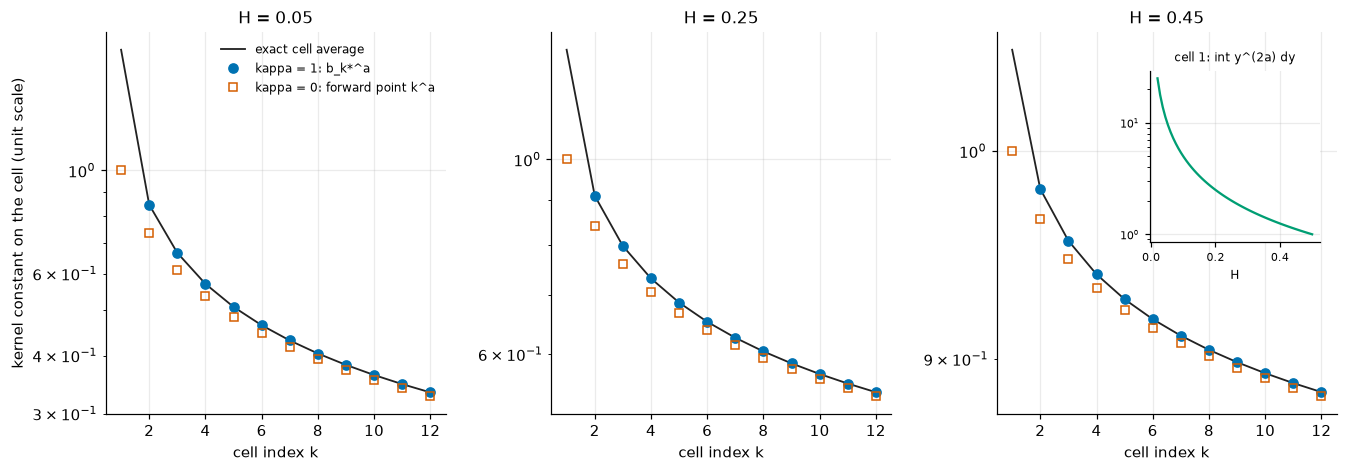

   H  exact mean of cell 1  forward constant of cell 1  L2 term 1/(2H)  smallest margin of b_k* (k>=2)
0.05                 1.818                         1.0          10.000                           0.459
0.25                 1.333                         1.0           2.000                           0.464
0.45                 1.053                         1.0           1.111                           0.470


In [7]:
Hs2 = [0.05, 0.25, 0.45]
ncell = 12
kk = np.arange(1, ncell + 1)
fig, ax = plt.subplots(1, 3, figsize=(12.5, 4.4), sharey=False)
rows = []
for j, H in enumerate(Hs2):
    a = H - 0.5
    exact = np.array([integrate.quad(lambda y: y ** a, k - 1, k)[0] if k > 1 else
                      integrate.quad(lambda y: 1.0, 0.0, 1.0, weight='alg', wvar=(a, 0.0))[0] for k in kk])
    g1 = kernel_weights(ncell, a, 1) * ncell ** a          # unit-cell scale: b_k^a for k >= 2, zero for k = 1
    g0 = kernel_weights(ncell, a, 0) * ncell ** a          # forward point k^a
    ax[j].plot(kk, exact, '-', color=PAL['black'], lw=1.2, label='exact cell average')
    ax[j].plot(kk[1:], g1[1:], 'o', color=PAL['blue'], ms=6, label='kappa = 1: b_k*^a')
    ax[j].plot(kk, g0, 's', color=PAL['vermillion'], ms=5, mfc='none', label='kappa = 0: forward point k^a')
    ax[j].set_yscale('log')
    ax[j].set_xlabel('cell index k'); ax[j].set_title(f'H = {H}')
    bsj = b_star(ncell, a)
    margin = np.minimum(bsj - (kk - 1), kk - bsj)[1:].min()
    rows.append({'H': H, 'exact mean of cell 1': exact[0], 'forward constant of cell 1': g0[0],
                 'L2 term 1/(2H)': 1 / (2 * H), 'smallest margin of b_k* (k>=2)': margin})
ax[0].set_ylabel('kernel constant on the cell (unit scale)')
ax[0].legend(fontsize=8)
ins = ax[2].inset_axes([0.45, 0.45, 0.5, 0.45])
Hg = np.linspace(0.02, 0.5, 60)
ins.plot(Hg, [integrate.quad(lambda y: 1.0, 0.0, 1.0, weight='alg', wvar=(2 * (h - 0.5), 0.0))[0] for h in Hg], color=PAL['green'])
ins.set_yscale('log'); ins.set_title('cell 1: int y^(2a) dy', fontsize=8); ins.set_xlabel('H', fontsize=8); ins.tick_params(labelsize=7)
fig.tight_layout()
show_fig(fig)
print(pd.DataFrame(rows).round(3).to_string(index=False))

**How to read.** Each marker is the constant the scheme uses on one cell and the line is the exact cell average. The $\kappa=1$ markers sit on the line, the forward markers sit below it (the kernel is decreasing, so its right-end value is smaller than its cell average), with a gap that is largest on the first cell. Cell 1 is the only visibly singular one: the exact average is finite there but the squared error term in the inset grows without bound as $H$ falls, which is why the first cell gets a joint Gaussian treatment instead of a constant.

**Mid-research figure:** does the scheme with the exact first cell match the exact covariance entry by entry, in standard-error units? Data: figures/fig-1.1.csv ($n=16$ steps, $T=0.5$, one panel per $H$). Each point is $|\widehat{\mathrm{Cov}}-\mathrm{Cov}_{exact}|/\mathrm{SE}$ for the entry $\mathrm{Cov}(\tilde W_{t_8},\tilde W_{t_{8+\ell}})$ on a log axis, one colour per $\kappa$, with a dashed line at three standard errors.

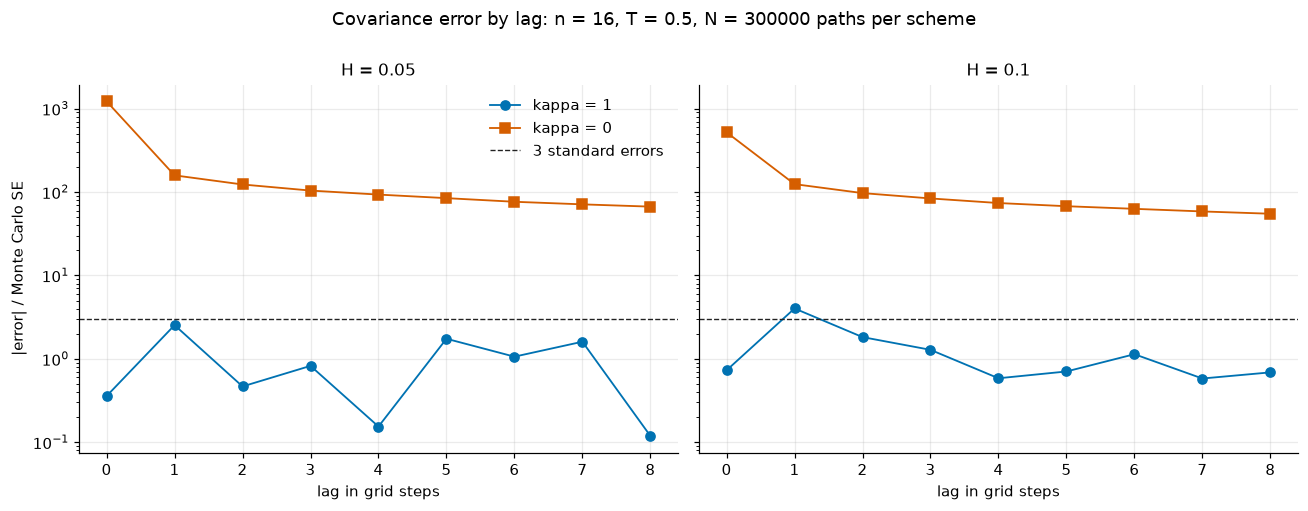

              min      max
kappa H                   
0     0.05  66.81  1220.90
      0.10  54.92   519.62
1     0.05   0.12     2.54
      0.10   0.58     4.02
provenance: [{'run_id': '2026-10-02T15:52:57', 'seed': 92, 'config_hash': '13cfe55e834c4eec'}, {'run_id': '2026-10-02T15:52:57', 'seed': 142, 'config_hash': '13cfe55e834c4eec'}, {'run_id': '2026-10-02T15:52:57', 'seed': 192, 'config_hash': '13cfe55e834c4eec'}, {'run_id': '2026-10-02T15:52:57', 'seed': 242, 'config_hash': '13cfe55e834c4eec'}]


In [8]:
fig1 = pd.read_csv('figures/fig-1.1.csv')
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for j, H in enumerate(sorted(fig1['H'].unique())):
    for kap, colour, mk in [(1, PAL['blue'], 'o'), (0, PAL['vermillion'], 's')]:
        d = fig1[(fig1['H'] == H) & (fig1['kappa'] == kap)].sort_values('lag')
        ax[j].plot(d['lag'], d['abs_error_over_se'], marker=mk, color=colour, lw=1.2, label=f'kappa = {kap}')
    ax[j].axhline(3.0, color=PAL['black'], ls='--', lw=0.9, label='3 standard errors')
    ax[j].set_yscale('log'); ax[j].set_xlabel('lag in grid steps'); ax[j].set_title(f'H = {H}')
ax[0].set_ylabel('|error| / Monte Carlo SE'); ax[0].legend()
n_in, T_in, N_in = int(fig1['n_steps'].iloc[0]), 0.5, int(fig1['n_paths'].iloc[0])
fig.suptitle(f'Covariance error by lag: n = {n_in}, T = {T_in}, N = {N_in} paths per scheme', y=1.0)
fig.tight_layout()
show_fig(fig)
print(fig1.groupby(['kappa', 'H'])['abs_error_over_se'].agg(['min', 'max']).round(2))
print('provenance:', fig1[['run_id', 'seed', 'config_hash']].drop_duplicates().to_dict('records'))

**How to read.** Each point is the distance between a simulated covariance entry and the exact one, in units of Monte Carlo standard error. Points near the dashed line are consistent with sampling noise; points far above it show discretisation error. The table gives the smallest and largest value per scheme and roughness.

**Post-research figure:** does the covariance error of the scheme stay at the level of the Monte Carlo noise as the grid is refined, compared with the exact benchmark of the source? One panel per $n\in\{8,16,32\}$ at $H$ equal to one tenth and $T=1$: the signed error $\widehat{\mathrm{Cov}}-\mathrm{Cov}_{exact}$ of the entry $\mathrm{Cov}(\tilde W_{T/2},\tilde W_{T/2+\ell h})$ against the lag $\ell$ in grid steps, with a shaded band of plus/minus three standard errors around zero, for $\kappa=1$ and $\kappa=0$. The exact covariance is the numerical integral of CHECK HY-4; CHECK HY-1 to HY-4 are printed above.

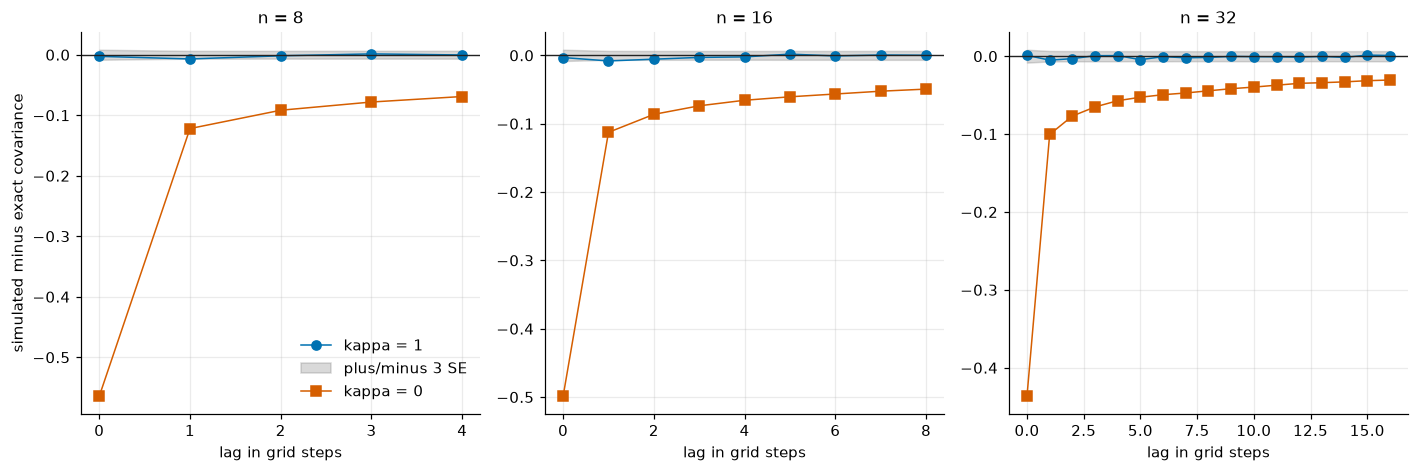

 n  kappa  error at lag 0  SE at lag 0  max |error|/SE  entries beyond 3 SE  mean signed error
 8      1        -0.00265      0.00275         3.22649                    1           -0.00205
 8      0        -0.56450      0.00097       581.35975                    5           -0.18506
16      1        -0.00317      0.00274         3.73708                    1           -0.00227
16      0        -0.49889      0.00117       425.76286                    9           -0.11736
32      1         0.00110      0.00275         2.28520                    0           -0.00101
32      0        -0.43662      0.00137       319.62032                   17           -0.07133


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4.4))
rows = []
Hq, Nq, Tq = 0.1, 200000, 1.0
for j, nq in enumerate([8, 16, 32]):
    i0q = nq // 2
    lags = np.arange(0, i0q + 1)
    ex = np.array([exact_cov(Hq, i0q * Tq / nq, (i0q + l) * Tq / nq) for l in lags])
    for kap, colour, mk in [(1, PAL['blue'], 'o'), (0, PAL['vermillion'], 's')]:
        Wq = simulate_volterra(Nq, nq, Tq, Hq, kappa=kap, rng=np.random.default_rng(SEED + 70 + 3 * j + kap))
        err, se = zip(*[cov_entry(Wq, i0q, i0q + l) for l in lags])
        err = np.array(err) - ex; se = np.array(se)
        del Wq
        ax[j].plot(lags, err, marker=mk, color=colour, lw=1.0, label=f'kappa = {kap}')
        if kap == 1:
            ax[j].fill_between(lags, -3 * se, 3 * se, color=PAL['grey'], alpha=0.25, label='plus/minus 3 SE')
        rows.append({'n': nq, 'kappa': kap, 'error at lag 0': err[0], 'SE at lag 0': se[0],
                     'max |error|/SE': np.max(np.abs(err) / se), 'entries beyond 3 SE': int((np.abs(err) > 3 * se).sum()),
                     'mean signed error': err.mean()})
    ax[j].axhline(0.0, color=PAL['black'], lw=0.9)
    ax[j].set_title(f'n = {nq}'); ax[j].set_xlabel('lag in grid steps')
ax[0].set_ylabel('simulated minus exact covariance'); ax[0].legend()
fig.tight_layout()
show_fig(fig)
print(pd.DataFrame(rows).round(5).to_string(index=False))

**How to read.** The shaded band is what sampling noise alone can produce, and the exact covariance is the zero line. A scheme that agrees with the benchmark of the source keeps its markers inside the band; agreement at plotting resolution is not agreement within this band. The $\kappa=0$ markers should sit far outside it at small lags.

**Interpretation.** With $\kappa=1$ the error against the exact covariance stays within a few standard errors at every lag (the largest value in the table of the mid figure is about four), whereas the forward sum is between roughly fifty and twelve hundred standard errors away, and worst at lag zero, where the first cell carries only the fraction $2H$ of the right variance (derivation step 6, verified directly by HY-3). In the post figure every plotted forward-sum entry lies outside the three-standard-error band at all three grid sizes, and its lag-zero error shrinks only by about a quarter when $n$ goes from 8 to 32: refining the grid does not repair it at a useful rate. Negative and surprising observation: $\kappa=1$ is not statistically exact. One entry per run exceeds three standard errors at the largest $N$ used here, and the mean signed error of the $\kappa=1$ path is negative at all three grid sizes, the direction of the one-sided variance deficit of derivation step 9. So the quoted statement that the smiles are indistinguishable from the exact Cholesky benchmark holds at plotting resolution; at Monte Carlo resolution the scheme has a small, measurable bias. The simulator of the later sections is therefore used as an approximation with a known sign of error, not as an exact sampler.

**Limits.** rhA-q11 (item 6) gives a falsifier on the maximum implied-volatility error against an exact Cholesky simulation with a million paths and 500 steps; this notebook does not run it (cost), and no trace states the error in covariance units. The quoted reduction of the asymptotic RMSE is a statement about a limiting constant (Eq 2.11 of the source), not about $n=16$ cells. rhA-q11 (item 4) concerns the bias of the change-of-frequency estimator at $\alpha=-0.45$, another estimator, and is not reproduced here. The exact Cholesky baseline is not part of the package API, so the oracle used here is the covariance integral.

## 3. Roughness

**Claim.** For a log-volatility series with fractional-Brownian-type increments, the empirical moments of increments scale as a power of the lag, $\zeta_q = qH$, so the slope of $\log m$ on $\log\Delta$ gives $\zeta_q$ and the slope of $\zeta_q$ on $q$ gives the roughness $H$. Replacing the spot variance by an integral of the variance over a window raises the recovered $H$, the direction reported in the source. Every number quoted below is the source's own.

source: rhA-q3-1410.3394

> $m(q, \Delta) = \frac{1}{N} \sum_{k=1}^N \left| \log(\sigma_{k\Delta}) - \log(\sigma_{(k-1)\Delta}) \right|^q$ (Section 2.1, definition as printed in the trace)

> "Under stationarity, $E[|\log \sigma_\Delta - \log \sigma_0|^q] = K_q \Delta^{\zeta_q}$", regression of $\log m$ on $\log \Delta$ for $q \in \{0.5, 1, 1.5, 2, 3\}$ and $\Delta = 1, \dots, 30$ days; "the scaling exponent follows the monofractal relation $\zeta_q \approx q H$"

> Table C.1 (Appendix C, analytic model with true $H = 0.140$): exact, $\delta = 0$: $\hat H = 0.140$, vol-of-vol $0.300$; UZ proxy, $\delta = 1/24$: $\hat H = 0.161$, $0.263$; RV proxy, $\delta = 1/3$: $\hat H = 0.184$, $0.230$

> "Note that in practice $\zeta_q$ is a slightly concave function of $q$." (quoted in rhA-q11, item 2, locator Section 2.1)

**Derivation, part 1: what the regression measures** (derived here). Notation: $a = H - \tfrac12$, $x_t = \log V_t$, $\tilde W_t = \sqrt{2H}\int_0^t (t-u)^a\,dW_u$.

1. Split the increment of the Volterra driver over $[t, t+\Delta]$ into the part driven by new noise and the part driven by old noise (Itô isometry on the two time sets, then the substitution $u = t - s$ scaled by $\Delta$):
$$\operatorname{Var}(\tilde W_{t+\Delta} - \tilde W_t) = \Delta^{2H}\Big[1 + 2H\int_0^{t/\Delta}\big((1+y)^a - y^a\big)^2\,dy\Big].$$
2. The integrand behaves like $a^2 y^{2a-2}$ for large $y$, and $2a - 2 < -1$, so the integral converges as $t/\Delta \to \infty$ to a constant $C_H$: away from the origin the increments are Gaussian with variance $\eta^2 C_H \Delta^{2H}$. The drift $-\tfrac{\eta^2}{2}t^{2H}$ of $\log V$ is smooth in $t$ and negligible next to the rough part.
3. For $Z \sim N(0, s^2)$ one has $E|Z|^q = s^q\,2^{q/2}\,\Gamma(\tfrac{q+1}{2})/\sqrt\pi$. Hence $E\,m(q,\Delta) = K_q\,\Delta^{qH}$ with $K_q = (\eta^2 C_H)^{q/2}\,2^{q/2}\Gamma(\tfrac{q+1}{2})/\sqrt\pi$, so $\zeta_q = qH$ is exactly linear in $q$ (a monofractal). This is the property the second regression tests.

**Derivation, part 2: the two regressions and their finite-sample bias** (derived here).

4. First regression, one per $q$: with $x_\ell = \log \ell$ and $y_\ell = \log m(q, \ell)$ for lags $\ell = 1, \dots, 30$,
$$\hat\zeta_q = \frac{\sum_\ell (x_\ell - \bar x)(y_\ell - \bar y)}{\sum_\ell (x_\ell - \bar x)^2}.$$
5. Second regression, with intercept: $\hat H = \sum_q (q - \bar q)(\hat\zeta_q - \bar\zeta)/\sum_q (q - \bar q)^2$. Under linearity the intercept is zero, so a nonzero intercept diagnoses a model that is not a monofractal.
6. $m(q,\Delta)$ averages $N_\Delta = \lfloor (L-1)/\Delta \rfloor$ terms, so its relative variance is $r_q(\Delta) \approx \kappa_q/N_\Delta \propto \Delta/L$. For independent Gaussian terms $\kappa_q = \sqrt\pi\,\Gamma(q + \tfrac12)/\Gamma(\tfrac{q+1}{2})^2 - 1$, which increases with $q$. Dependence between increments changes the constant, not the order.
7. By the second-order expansion of the logarithm, $E\log m \approx \log E m - \tfrac12 r_q(\Delta)$. The correction $-\tfrac12 r_q(\Delta)$ is more negative at large lags, because fewer terms are averaged there, so it lowers the fitted slope. It is larger for large $q$ by step 6. Two consequences follow: $\hat H$ is biased downward in short series, and $\hat\zeta_q$ is concave in $q$, which is the quoted remark. Both effects scale like $1/L$; the size is not claimed to be exact.
8. The Volterra process is not stationary near $t = 0$: the correction in step 1 is of order $(t/\Delta)^{2a-1}$ there. Very short series therefore carry a start-up bias in addition to step 7.

**Derivation, part 3: smoothing by an integrated-variance proxy** (derived here).

9. Let $Y_t = \frac1\delta\int_{t-\delta}^{t} X_s\,ds$ where $X$ has stationary increments and variogram $\gamma(r) = c\,|r|^{2H}$. With $w = u - v$,
$$\operatorname{Var}(Y_{t+\Delta} - Y_t) = \frac{1}{\delta^2}\int_0^\delta\!\!\int_0^\delta \tfrac12\big[\gamma(\Delta + w) + \gamma(\Delta - w) - 2\gamma(w)\big]\,du\,dv.$$
For $\Delta \le \delta$ the first-order expansion $Y_{t+\Delta} - Y_t \approx \frac{\Delta}{\delta}(X_t - X_{t-\delta})$ gives variance of order $(\Delta/\delta)^2\,c\,\delta^{2H}$: a local exponent $2$, which is a smooth path. For $\Delta \gg \delta$ the exponent returns to $2H$.
10. With a window $\delta$ of order one observation and lags $1, \dots, 30$, the fitted line mixes the exponent-$2$ part at the smallest lags with the exponent-$2H$ part at larger lags. The fitted slope rises, so $\hat H > H$. This gives the sign of the bias in `Table C.1` and the drop of the estimated vol-of-vol there (averaging removes amplitude). The argument gives the sign, not the size.
11. The package proxy averages the left points of the window of fine steps. Taking $\log$ of the mean differs from the mean of the $\log$ by Jensen's inequality, a second and smaller effect.
12. Forward-sum scheme ($\kappa = 0$): the first fine cell has variance $2H$ times the right value (the Hybrid scheme section, first-cell argument). Increments at the smallest lags are then too small relative to large lags, the fitted slope is too steep, and $\hat H$ is too large, most for small $H$. This is the direction of the statement in rhA-q11, item 4: "When $\kappa = 0$, the estimator suffers from severe positive bias for $\alpha < 0$, which gets worse as $\alpha \to -1/2$", which concerns a different estimator, so only the sign transfers.

In [10]:
from rough_hedge import rbergomi, roughness

# Study design: N_SER independent series per H, L observation days, SPD fine steps per day.
N_SER, L, SPD = 40, 2000, 8
HS = (0.1, 0.3)
QS = (0.5, 1.0, 1.5, 2.0, 3.0)
LOGV, VFINE = {}, {}
with np.errstate(all="ignore"):
    for H in HS:
        out = rbergomi.simulate_rbergomi(N_SER, SPD * L, L / 252, H, 1.9, -0.7, 0.04,
                                         rng=np.random.default_rng(7000 + int(100 * H)))
        VFINE[H] = out["V"]                 # fine-grid variance, index 0..SPD*L
        LOGV[H] = np.log(out["V"][:, ::SPD])  # spot log-variance at the observation times
print("series per H:", N_SER, "| observations per series:", LOGV[0.1].shape[1], "| fine steps per day:", SPD)

series per H: 40 | observations per series: 2001 | fine steps per day: 8


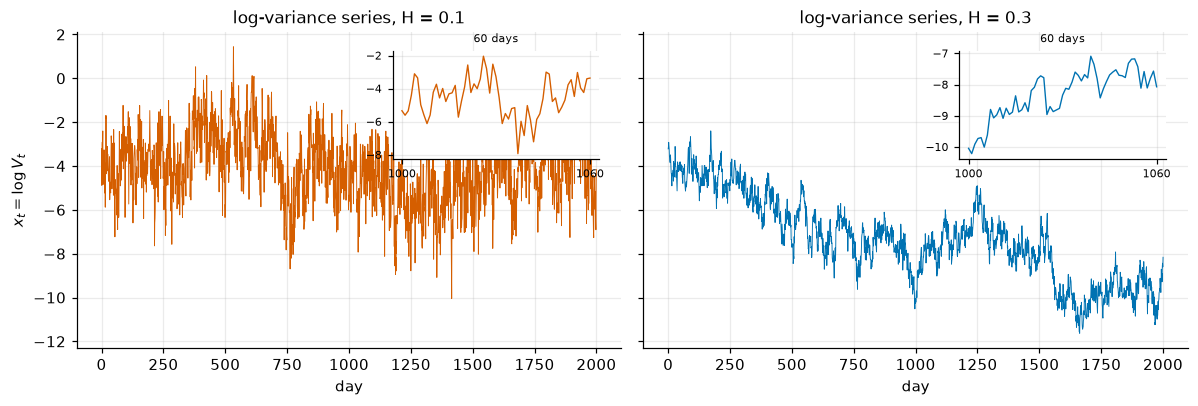

In [11]:
# Pre-research figure: log-variance series for two roughness values, before any estimator
ROUGH_COL = {0.1: "#D55E00", 0.3: "#0072B2"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, H in zip(axes, HS):
    x = LOGV[H][0]
    ax.plot(np.arange(len(x)), x, lw=0.6, color=ROUGH_COL[H])
    ax.set_title(f"log-variance series, H = {H}")
    ax.set_xlabel("day")
    ax.grid(alpha=0.25)
    ins = ax.inset_axes([0.58, 0.60, 0.38, 0.34])
    ins.plot(np.arange(1000, 1061), x[1000:1061], lw=0.9, color=ROUGH_COL[H])
    ins.set_xticks([1000, 1060])
    ins.tick_params(labelsize=7)
    ins.set_title("60 days", fontsize=7)
axes[0].set_ylabel(r"$x_t = \log V_t$")
fig.tight_layout()
plt.show()

**How to read.** Each panel is one simulated log-variance series of the study length. The series with the smaller $H$ moves in short irregular steps; the series with the larger $H$ is smoother over the same horizon. The inset zooms on sixty days of the same series.

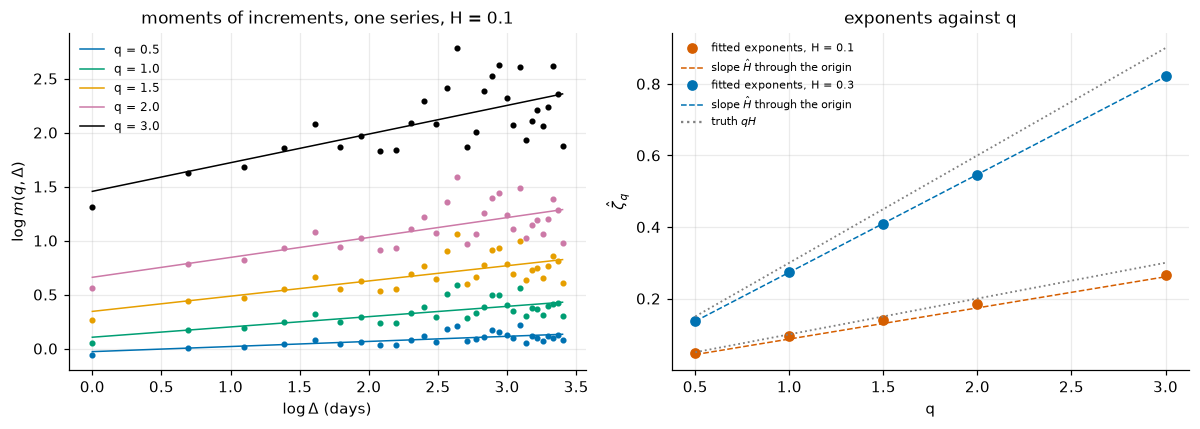

In [12]:
# Mid-research figure: how the scaling regression turns increments into an estimate of H
LAGS = np.arange(1, 31)
xs = LOGV[0.1][0]
zhat = roughness.zeta_exponents(xs)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))
cmap = ["#0072B2", "#009E73", "#E69F00", "#CC79A7", "#000000"]
for q, z, c in zip(QS, zhat, cmap):
    m = np.array([roughness.moment_m(xs, q, int(l)) for l in LAGS])
    lx, ly = np.log(LAGS), np.log(m)
    a1.plot(lx, ly, "o", ms=3, color=c)
    a1.plot(lx, ly.mean() + z * (lx - lx.mean()), "-", lw=1, color=c, label=f"q = {q}")
a1.set_xlabel(r"$\log \Delta$ (days)")
a1.set_ylabel(r"$\log m(q, \Delta)$")
a1.set_title("moments of increments, one series, H = 0.1")
a1.legend(fontsize=8)
a1.grid(alpha=0.25)
qq = np.array(QS)
for H in HS:
    zh = roughness.zeta_exponents(LOGV[H][0])
    Hh = roughness.estimate_hurst(LOGV[H][0])[0]
    a2.plot(qq, zh, "o", color=ROUGH_COL[H], label=f"fitted exponents, H = {H}")
    a2.plot(qq, Hh * qq, "--", lw=1, color=ROUGH_COL[H], label=r"slope $\hat H$ through the origin")
    a2.plot(qq, H * qq, ":", lw=1.2, color="grey")
a2.plot([], [], ":", color="grey", label="truth $qH$")
a2.set_xlabel("q")
a2.set_ylabel(r"$\hat\zeta_q$")
a2.set_title("exponents against q")
a2.legend(fontsize=7)
a2.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**How to read.** On the left each line is a moment of increments against the lag, and its slope is the exponent for that $q$. On the right the exponents against $q$ should fall near a straight line whose slope is the roughness; the dotted grey line is the truth, and any bend of the points away from the dashed line is the finite-sample concavity of derivation step 7.

In [13]:
# CHECK ROUGH-1 / ROUGH-2: recovery and linearity on N_SER independent series per H
HAT, ZETA = {}, {}
for H in HS:
    HAT[H] = roughness.estimate_hurst(LOGV[H])[0]
    ZETA[H] = roughness.zeta_exponents(LOGV[H])
    m, se = HAT[H].mean(), HAT[H].std(ddof=1) / np.sqrt(N_SER)
    CHECK(f"ROUGH-1: recovered H, mean over series, true H={H} (SE={se:.4f}, band is a design choice)",
          abs(m - H) <= 0.02 and se <= 0.005, m, f"|mean-H|<=0.02 and SE<=0.005, |mean-H|={abs(m - H):.4f}")
for H in HS:
    R = ZETA[H][:, 4] / (2 * ZETA[H][:, 2])          # zeta_3 / (2 zeta_1.5), equals 1 under linearity
    m, se = R.mean(), R.std(ddof=1) / np.sqrt(N_SER)
    CHECK(f"ROUGH-2: linearity ratio zeta_3/(2 zeta_1.5), H={H} (SE={se:.4f}, 0.05 is a design allowance)",
          abs(m - 1) <= 4 * se + 0.05, m, f"|R-1|<=4SE+0.05={4 * se + 0.05:.4f}, signed R-1={m - 1:+.4f}")

CHECK ROUGH-1: recovered H, mean over series, true H=0.1 (SE=0.0025, band is a design choice) | observed=0.09159 | expected=|mean-H|<=0.02 and SE<=0.005, |mean-H|=0.0084 | PASS


CHECK ROUGH-1: recovered H, mean over series, true H=0.3 (SE=0.0031, band is a design choice) | observed=0.2974 | expected=|mean-H|<=0.02 and SE<=0.005, |mean-H|=0.0026 | PASS
CHECK ROUGH-2: linearity ratio zeta_3/(2 zeta_1.5), H=0.1 (SE=0.0077, 0.05 is a design allowance) | observed=0.9729 | expected=|R-1|<=4SE+0.05=0.0808, signed R-1=-0.0271 | PASS
CHECK ROUGH-2: linearity ratio zeta_3/(2 zeta_1.5), H=0.3 (SE=0.0037, 0.05 is a design allowance) | observed=0.9942 | expected=|R-1|<=4SE+0.05=0.0647, signed R-1=-0.0058 | PASS


In [14]:
# CHECK ROUGH-3 / ROUGH-4 and the domain line (same series as above, paired comparisons)
H0 = 0.1
spot = HAT[H0]
sh = {}
for win in (1, 8):
    with np.errstate(all="ignore"):
        px = np.log(roughness.integrated_variance_proxy(VFINE[H0], SPD, win))
    sh[win] = roughness.estimate_hurst(px)[0] - spot
d = sh[8]
z = d.mean() / (d.std(ddof=1) / np.sqrt(N_SER))
CHECK("ROUGH-3a: proxy (window 8) minus spot H_hat, paired, H=0.1", z >= 4, d.mean(), f"z={z:.1f}>=4 (positive bias)")
dd = sh[8] - sh[1]
z = dd.mean() / (dd.std(ddof=1) / np.sqrt(N_SER))
CHECK("ROUGH-3b: window-8 shift minus window-1 shift, paired, H=0.1", z >= 4, dd.mean(), f"z={z:.1f}>=4 (larger window, larger bias)")
short = roughness.estimate_hurst(LOGV[H0][:, :250])[0]
dl = spot - short
z = dl.mean() / (dl.std(ddof=1) / np.sqrt(N_SER))
CHECK("ROUGH-4: full-length H_hat minus H_hat from 250 observations, paired, H=0.1", z >= 4, dl.mean(), f"z={z:.1f}>=4 (short series biased down); mean short={short.mean():.3f}")
try:
    roughness.moment_m(LOGV[H0][0, :2], 1.0, 1)
    raised = 0
except ValueError:
    raised = 1
CHECK("ROUGH-5: moment_m on 2 points raises ValueError (domain)", raised == 1, raised, "raised=1")

CHECK ROUGH-3a: proxy (window 8) minus spot H_hat, paired, H=0.1 | observed=0.08938 | expected=z=37.0>=4 (positive bias) | PASS
CHECK ROUGH-3b: window-8 shift minus window-1 shift, paired, H=0.1 | observed=0.08769 | expected=z=35.2>=4 (larger window, larger bias) | PASS


CHECK ROUGH-4: full-length H_hat minus H_hat from 250 observations, paired, H=0.1 | observed=0.02897 | expected=z=5.0>=4 (short series biased down); mean short=0.063 | PASS
CHECK ROUGH-5: moment_m on 2 points raises ValueError (domain) | observed=1 | expected=raised=1 | PASS


        series  H_true  H_hat_mean  H_hat_se   bias  bias_over_se  n_paths
          spot    0.05       0.041     0.001 -0.009        -6.549      100
     proxy_day    0.05       0.119     0.002  0.069        36.524      100
forward_kappa0    0.05       0.155     0.002  0.105        59.671      100
          spot    0.10       0.097     0.002 -0.003        -1.427      100
     proxy_day    0.10       0.186     0.002  0.086        41.219      100
forward_kappa0    0.10       0.184     0.002  0.084        36.154      100
          spot    0.20       0.200     0.002 -0.000        -0.194      100
     proxy_day    0.20       0.277     0.002  0.077        33.573      100
forward_kappa0    0.20       0.247     0.003  0.047        18.111      100
          spot    0.30       0.302     0.002  0.002         0.744      100
     proxy_day    0.30       0.359     0.002  0.059        24.664      100
forward_kappa0    0.30       0.322     0.003  0.022         7.582      100
          spot    0.45   

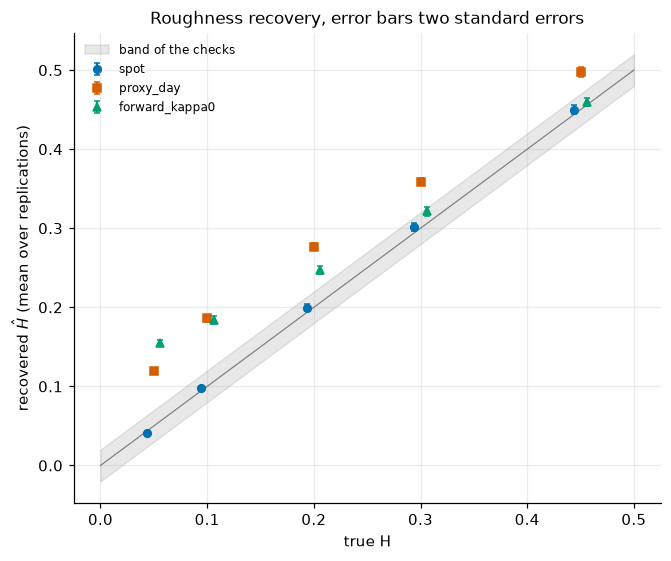

In [15]:
# Post-research figure: recovered H against true H, from figures/fig-1.2.csv
df12 = pd.read_csv("figures/fig-1.2.csv")
df12["bias"] = df12["H_hat_mean"] - df12["H_true"]
df12["bias_over_se"] = df12["bias"] / df12["H_hat_se"]
print(df12[["series", "H_true", "H_hat_mean", "H_hat_se", "bias", "bias_over_se", "n_paths"]].round(3).to_string(index=False))
sty = {"spot": ("#0072B2", "o", -0.006), "proxy_day": ("#D55E00", "s", 0.0), "forward_kappa0": ("#009E73", "^", 0.006)}
fig, ax = plt.subplots(figsize=(6.2, 5.2))
grid = np.linspace(0, 0.5, 50)
ax.fill_between(grid, grid - 0.02, grid + 0.02, color="grey", alpha=0.18, label="band of the checks")
ax.plot(grid, grid, color="grey", lw=0.8)
for name, (c, mk, off) in sty.items():
    s = df12[df12["series"] == name]
    ax.errorbar(s["H_true"] + off, s["H_hat_mean"], yerr=2 * s["H_hat_se"], fmt=mk, color=c, ms=5, capsize=2, label=name)
ax.set_xlabel("true H")
ax.set_ylabel(r"recovered $\hat H$ (mean over replications)")
ax.set_title("Roughness recovery, error bars two standard errors")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**How to read.** Points on the diagonal mean the roughness is recovered, and the shaded band is the tolerance used in the checks. Series above the diagonal overstate $H$, which is the direction of the bias reported in the source. Error bars are two standard errors of the mean over replications; the printed table gives the offset from the truth in units of one standard error.

**Interpretation.** The spot series recovers the roughness over the whole range tested, with a small downward offset at the smallest $H$ that is larger than its error bar but stays inside the band: the finite-length effect of derivation step 7, confirmed by the paired check on short series. The integrated-variance proxy sits above the diagonal at every $H$, in the direction of `Table C.1`; its window here is a full day, longer than the windows of the source, so the size is not comparable. The forward-sum series also sits above the diagonal at every $H$, in the direction of derivation step 12; how its gap compares with the proxy gap depends on $H$ and is read from the printed table. Negative result: the two biases have opposite signs. Finite length pushes the estimate down and smoothing pushes it up, so a recovered value close to the truth in real data can hide both.

**Limits.** **Limits.** The source reports one simulated truth, $H = 0.14$ with 2000 days, and its `Table C.1` comes from an analytic fractional Stein-Stein model, not from the rough Bergomi driver used here, so only the signs transfer. The falsifier proposed in rhA-q11, item 2, uses the ratio $(\zeta_3 - \zeta_1)/(2\zeta_{1.5})$ with thresholds that cannot hold under exact linearity, since that ratio then equals $2/3$; the ratio used in ROUGH-2 is the corrected one (derived here). Time-varying roughness (rhA-q11, item 3) and the equality of the exponents under the physical and pricing measures (item 5) are empirical statements that simulated data cannot test. No trace gives a standard error of the regression at finite length for this estimator.

## 4. Monte Carlo estimators

**Claim.** Conditioning on the volatility driver and a timer-option control variate reduce the variance of the price estimator, and a runtime-adjusted error measure turns variance ratios into runtime ratios. Only the ordering of estimators is compared with the source below; the source's absolute levels depend on its own implementation and units.

source: rhA-q4-1708.02563

> $X = \mathrm{BS}\big((1-\rho^2)\int_0^t V_u\,du ;\, S^1_t, k\big)$, $Y = \mathrm{BS}\big(\rho^2(\widehat Q_n - \int_0^t V_u\,du) ;\, S^1_t, k\big)$ (mixed estimator, Equation 2.4, Table 1)

> $\hat\alpha_n := - \frac{\sum_i (X_i - \bar X_n)(Y_i - \bar Y_n)}{\sum_i (Y_i - \bar Y_n)^2}$, $\widehat Q_n := \sup\{(\int_0^t V_u\,du)_i : i = 1, \dots, n\}$ (Equation 2.5)

> From rhA-q7, Section 3.1, p. 9: "we may therefore use ratios of estimator $\psi^2$ values in order to approximate the relative runtime to achieve a fixed $\phi$ value ... since $\tau = \psi^2 / \phi^2$"; and $\psi^2 := \frac{\tau}{m}\sum_{i=1}^m \hat\sigma^2_{n,N,k_i}$ (Equation 3.1)

> From rhA-q7, Section 3.2: "suggest a 13-fold runtime reduction in the $\rho = -0.9$ regime, and a 34-fold runtime reduction in the $\rho = 0$ regime"; Section 2: "the improvement is not dramatic" (Sobol sequences)

> Table 3, $\rho = -0.9$, 10 delta put, standard deviation in percentage points of implied volatility: Base 1.28, Antithetic 1.70, Conditional 1.19, Controlled 0.82, Mixed 0.55

**Derivation, part 1: conditioning and the control variate** (derived here). Let $G = \mathcal F^1_T \vee \mathcal F^2_0$ and $IV = \int_0^T V_u\,du$.

1. Split the log price into the part driven by $W^1$ and the part driven by the independent $W^2$:
$$\log S_T = \underbrace{\rho\!\int\!\sqrt V\,dW^1 - \tfrac{\rho^2}{2}IV}_{\log S^1_T} + \sqrt{1-\rho^2}\!\int\!\sqrt V\,dW^2 - \tfrac{1-\rho^2}{2}IV.$$
2. Given $G$, the integrand of the $W^2$ integral is deterministic, so the integral is $N(0, IV)$ (Wiener integral of a deterministic function). Hence $S_T \mid G$ is lognormal with mean $S^1_T$ and total variance $(1-\rho^2)IV$.
3. The conditional expectation of the call is a Black-Scholes value in total-variance form, $E[(S_T - K)^+ \mid G] = \mathrm{BS}\big((1-\rho^2)IV;\, S^1_T, K\big)$, and the tower property makes it unbiased.
4. By the law of total variance, $\operatorname{Var}X = E[\operatorname{Var}(X \mid G)] + \operatorname{Var}(E[X \mid G]) \ge \operatorname{Var}(E[X \mid G])$, with equality iff $X$ is $G$-measurable. Conditioning cannot increase the variance; it costs one Black-Scholes evaluation per path.
5. For $Z = X + \alpha Y$ with $EY$ known, $\operatorname{Var}Z = \operatorname{Var}X + 2\alpha\operatorname{Cov}(X,Y) + \alpha^2\operatorname{Var}Y$ is a convex quadratic in $\alpha$. It is minimised at $\alpha^* = -\operatorname{Cov}(X,Y)/\operatorname{Var}Y$, the population version of Equation 2.5, with minimum $\operatorname{Var}X\,(1 - \operatorname{corr}(X,Y)^2)$. The correlation, not the sample size, sets the reduction.
6. Why $EY$ is known: let $M = \int\sqrt V\,dW^1$. By the Dambis-Dubins-Schwarz theorem $M_t = B_{\langle M\rangle_t}$ for a Brownian motion $B$, with $\langle M\rangle_T = IV$. If $Q \ge IV$ almost surely, run $B$ from $IV$ to $Q$ with independent Gaussian increments of variance $\rho^2(Q - IV)$ on the log scale (strong Markov property at the stopping time $IV$). Then $\rho B_Q - \tfrac{\rho^2}{2}Q$ is a Brownian motion with drift, whose exponential has mean one, so $E\,\mathrm{BS}\big(\rho^2(Q-IV);\, S^1, K\big) = \mathrm{BS}(\rho^2 Q;\, 1, K)$. With $Q$ replaced by the sample maximum the property holds only approximately, which creates an $O(1/n)$ bias, and the estimated $\hat\alpha$ adds another.

**Derivation, part 2: antithetic pairs, rate, and the runtime-adjusted measure** (derived here).

7. Antithetic pairs average $Z_j = \tfrac12(X_j + X_{j+h})$, $j < h = n/2$, so $\operatorname{Var}Z_j = \tfrac12\operatorname{Var}X\,(1 + \operatorname{corr}(X_j, X_{j+h}))$. A reduction needs a negative correlation of the payoff within a pair, and a call payoff is not monotone in the pair's common noise: it can be positive or negative. The average of the $h$ pair averages equals the plain sample mean of the same $n$ payoffs exactly, so evaluated on one antithetic-structured sample the antithetic price equals the base price to machine precision and only the reported standard error differs. An honest comparison therefore needs independent samples for the two methods.
8. For iid $Z_i$ with variance $\sigma^2$ the central limit theorem gives $\sqrt n(\bar Z - \mu) \Rightarrow N(0, \sigma^2)$: the error is proportional to $n^{-1/2}$ and $\widehat{SE} = \operatorname{sd}(Z)/\sqrt n$. Replacing $\sigma$ by $\sigma\sqrt{1-c^2}$ for a control with squared correlation $c^2$ changes the constant, not the exponent.
9. Runtime-adjusted measure: $\phi^2 = \frac1m\sum_k\hat\sigma_k^2$ with $\hat\sigma_k^2 = \sum_i(\hat\sigma_{ik} - \sigma_k)^2/(N-1)$ and $\psi^2 = \tau\phi^2$ (Equation 3.1). Since $\phi^2 \propto 1/n$ and the runtime $\tau \propto n$ for a fixed algorithm, $\tau\phi^2$ does not depend on $n$. The time to reach a target $\phi_*^2$ is $\tau n_*$ with $n_* = n\phi^2/\phi_*^2$, i.e. $\psi^2/\phi_*^2$, so ratios of $\psi^2$ are ratios of runtimes at equal accuracy. The statement is only as good as $\phi^2 \propto 1/n$ and $\tau \propto n$; a fixed overhead per estimate breaks the second.
10. An implied volatility is a smooth function of the price, so by the delta method $\operatorname{sd}(\hat\sigma^{BS}) \approx \operatorname{sd}(\hat P)/\mathrm{vega}$. Price-level and volatility-level comparisons then agree on the ranking of estimators at a fixed strike, which is why the price-level checks below speak to the volatility-level figure.

In [16]:
from rough_hedge import pricing

XI = 0.235 ** 2                                   # flat forward variance
KW = dict(T=0.25, H=0.07, eta=1.9, rho=-0.9, xi0=XI)
RHO = KW["rho"]
NAMES = ["base", "antithetic", "conditional", "controlled", "mixed"]
with np.errstate(all="ignore"):
    SMP = pricing.simulate_pricing_sample(n_paths=40000, n_steps=24, seed=11, antithetic=True, **KW)
    XP = np.maximum(SMP["ST"] - 1.0, 0.0)                                    # payoff, strike one
    QMAX = SMP["IV"].max()
    YP = pricing.bs_call_total_var(SMP["ST"], 1.0, QMAX - SMP["IV"])         # control variable of the controlled estimator
print("paths:", len(XP), "| share of zero payoffs:", round(float((XP == 0).mean()), 3), "| corr(X, Y):", round(float(np.corrcoef(XP, YP)[0, 1]), 3))

paths: 40000 | share of zero payoffs: 0.422 | corr(X, Y): 0.822


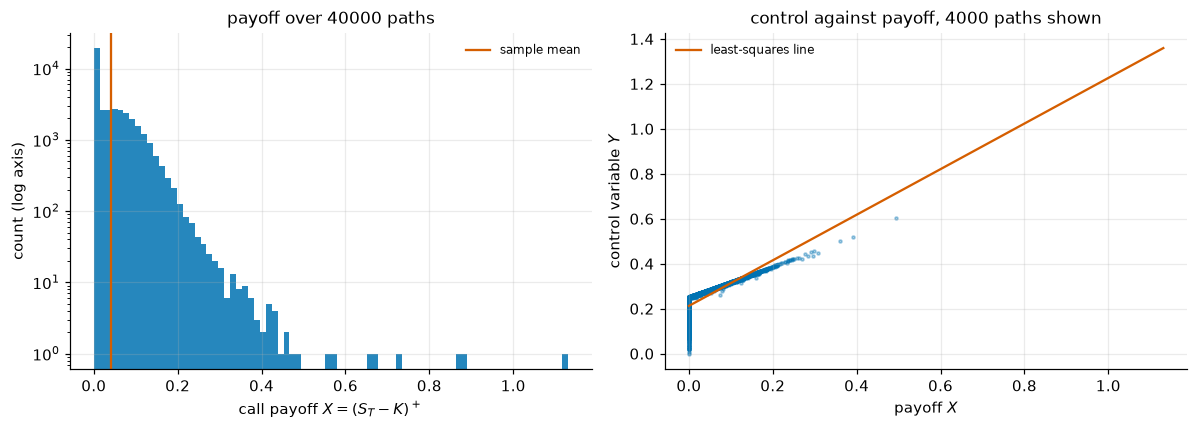

In [17]:
# Pre-research figure: payoff and control variable across paths, before any variance reduction
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))
a1.hist(XP, bins=80, color="#0072B2", alpha=0.85)
a1.set_yscale("log")
a1.axvline(XP.mean(), color="#D55E00", lw=1.5, label="sample mean")
a1.set_xlabel(r"call payoff $X = (S_T - K)^+$")
a1.set_ylabel("count (log axis)")
a1.legend(fontsize=8)
a1.set_title("payoff over 40000 paths")
idx = np.random.default_rng(3).choice(len(XP), 4000, replace=False)
a2.scatter(XP[idx], YP[idx], s=4, alpha=0.35, color="#0072B2")
slope, icpt = np.polyfit(XP, YP, 1)
xx = np.linspace(0, XP.max(), 50)
a2.plot(xx, slope * xx + icpt, color="#D55E00", lw=1.5, label="least-squares line")
a2.set_xlabel(r"payoff $X$")
a2.set_ylabel(r"control variable $Y$")
a2.set_title("control against payoff, 4000 paths shown")
a2.legend(fontsize=8)
fig.tight_layout()
plt.show()

**How to read.** Each panel shows a raw quantity the estimators work with. The left histogram shows the mass at zero payoff and the heavy right tail. The point cloud on the right shows how much of the payoff variation a control could remove: the tighter the cloud about the line, the larger the reduction.

In [18]:
# CHECK MC-1 / MC-2: agreement of the five estimators and exact variance identities on one antithetic sample
with np.errstate(all="ignore"):
    EST = {m: pricing.price_estimate(m, SMP, 1.0, RHO) for m in NAMES}
zs = [abs(EST[m].price - EST["base"].price) / np.sqrt(EST[m].stderr ** 2 + EST["base"].stderr ** 2) for m in NAMES[1:]]
CHECK("MC-1: max |price_m - price_base| / sqrt(se_m^2 + se_base^2) over four methods (conservative, shared paths)",
      max(zs) <= 4, max(zs), "z<=4")

dgap = abs(EST["antithetic"].price - EST["base"].price)
CHECK("MC-2a: antithetic price equals base price on the same sample (derivation step 7)", dgap <= 1e-12, dgap,
      f"<=1e-12; stderr ratio antithetic/base={EST['antithetic'].stderr / EST['base'].stderr:.3f}")

with np.errstate(all="ignore"):
    X = np.maximum(SMP["ST"] - 1.0, 0.0)
    Y = pricing.bs_call_total_var(SMP["ST"], 1.0, SMP["IV"].max() - SMP["IV"])
al = pricing.control_coefficient(X, Y)
c2 = np.corrcoef(X, Y)[0, 1] ** 2
vx = X.var(ddof=1)
o1 = abs((X + al * Y).var(ddof=1) / vx - (1 - c2))
o2 = abs(EST["controlled"].stderr ** 2 * len(X) / vx - (1 - c2))
CHECK("MC-2b: Var(X + alpha Y)/Var(X) = 1 - corr^2 at the sample alpha", o1 <= 1e-9, o1, f"<=1e-9; corr^2={c2:.3f}")
CHECK("MC-2b': reported stderr^2 n / Var(X) = 1 - corr^2", o2 <= 1e-9, o2, "<=1e-9")
v0 = (X + al * Y).var(ddof=1)
inc = min((X + f * al * Y).var(ddof=1) - v0 for f in (1.05, 0.95))
CHECK("MC-2c: variance at 1.05 alpha and 0.95 alpha both exceed variance at alpha (minimum increase)", inc > 0, inc, ">0")

CHECK MC-1: max |price_m - price_base| / sqrt(se_m^2 + se_base^2) over four methods (conservative, shared paths) | observed=0.7091 | expected=z<=4 | PASS
CHECK MC-2a: antithetic price equals base price on the same sample (derivation step 7) | observed=6.939e-18 | expected=<=1e-12; stderr ratio antithetic/base=0.910 | PASS
CHECK MC-2b: Var(X + alpha Y)/Var(X) = 1 - corr^2 at the sample alpha | observed=1.721e-15 | expected=<=1e-9; corr^2=0.675 | PASS
CHECK MC-2b': reported stderr^2 n / Var(X) = 1 - corr^2 | observed=1.665e-15 | expected=<=1e-9 | PASS
CHECK MC-2c: variance at 1.05 alpha and 0.95 alpha both exceed variance at alpha (minimum increase) | observed=4.815e-06 | expected=>0 | PASS


In [19]:
# CHECK MC-3: the base estimator error decays like n^(-1/2); independent samples at each size
R3 = 200
sd3 = {}
with np.errstate(all="ignore"):
    for n, base_seed in ((500, 20000), (8000, 30000)):
        p = np.array([pricing.price_estimate("base", pricing.simulate_pricing_sample(n_paths=n, n_steps=24, seed=base_seed + r, antithetic=False, **KW), 1.0, RHO).price
                      for r in range(R3)])
        sd3[n] = p.std(ddof=1)
slope3 = np.log(sd3[8000] / sd3[500]) / np.log(16)
se3 = 1 / (np.sqrt(R3 - 1) * np.log(16))
z3 = abs(slope3 + 0.5) / se3
CHECK("MC-3: slope of log sd(price) on log n, base estimator, n in (500, 8000)", z3 <= 4, slope3, f"-0.5 within z<=4, z={z3:.2f}, SE={se3:.3f}")

CHECK MC-3: slope of log sd(price) on log n, base estimator, n in (500, 8000) | observed=-0.5091 | expected=-0.5 within z<=4, z=0.36, SE=0.026 | PASS


In [20]:
# CHECK MC-4: independent antithetic comparison, and the runtime-adjusted identity
R4, N4 = 200, 1000
pb, pa = np.empty(R4), np.empty(R4)
with np.errstate(all="ignore"):
    for r in range(R4):
        pb[r] = pricing.price_estimate("base", pricing.simulate_pricing_sample(n_paths=N4, n_steps=24, seed=50000 + r, antithetic=False, **KW), 1.0, RHO).price
        pa[r] = pricing.price_estimate("antithetic", pricing.simulate_pricing_sample(n_paths=N4, n_steps=24, seed=60000 + r, antithetic=True, **KW), 1.0, RHO).price
ratio = pa.var(ddof=1) / pb.var(ddof=1)
se_lr = np.sqrt(4 / (R4 - 1))
CHECK("MC-4a: variance ratio antithetic/base on independent samples, n=1000",
      abs(np.log(ratio)) <= 4 * se_lr or ratio < 1, ratio, f"ratio within 4 SE of 1 or below; SE of log ratio={se_lr:.3f}")
rg = np.random.default_rng(5)
est_syn = rg.normal(0.0, 0.01, size=(500, 3))
true_syn = np.array([0.0, 0.001, -0.002])
tau_syn = 2.5
ra = pricing.runtime_adjusted_errors(est_syn, true_syn, tau_syn)
direct = np.mean(((est_syn - true_syn) ** 2).sum(axis=0) / (est_syn.shape[0] - 1))
obs = max(abs(ra.psi2 - tau_syn * ra.phi2) / (tau_syn * ra.phi2), abs(ra.phi2 - direct) / ra.phi2)
CHECK("MC-4b: runtime-adjusted measure, psi2 = tau phi2 and phi2 against a direct numpy value", obs <= 1e-12, obs, "<=1e-12")

CHECK MC-4a: variance ratio antithetic/base on independent samples, n=1000 | observed=0.7185 | expected=ratio within 4 SE of 1 or below; SE of log ratio=0.142 | PASS
CHECK MC-4b: runtime-adjusted measure, psi2 = tau phi2 and phi2 against a direct numpy value | observed=0 | expected=<=1e-12 | PASS


estimator     base  antithetic  conditional  controlled    mixed
n_paths                                                         
250        0.00353     0.00281      0.00277     0.00179  0.00129
500        0.00260     0.00191      0.00199     0.00121  0.00097
1000       0.00167     0.00154      0.00135     0.00095  0.00073
2000       0.00111     0.00105      0.00088     0.00069  0.00050
4000       0.00082     0.00073      0.00065     0.00044  0.00037
8000       0.00061     0.00054      0.00048     0.00034  0.00026
fitted log-log slopes: {'base': -0.52, 'antithetic': -0.473, 'conditional': -0.518, 'controlled': -0.48, 'mixed': -0.464}
max |antithetic / base - 1| over path counts: 0.266


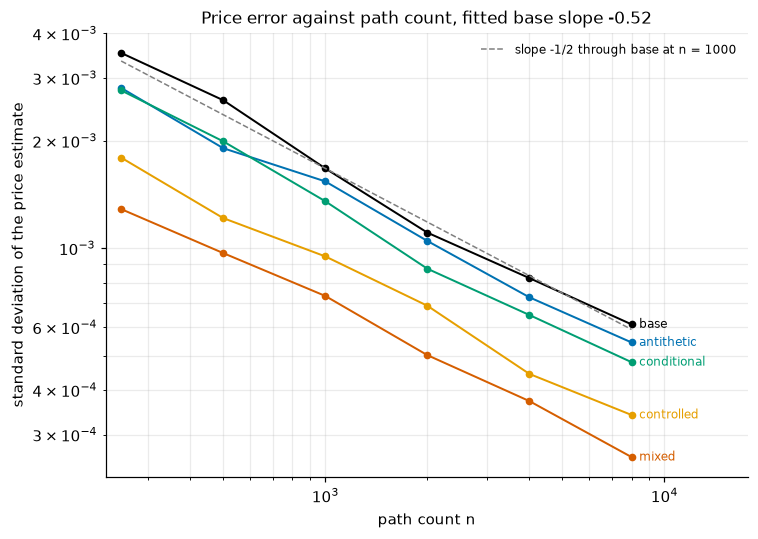

In [21]:
# Mid-research figure: price error against path count, from figures/fig-1.4.csv
df14 = pd.read_csv("figures/fig-1.4.csv")
ORDER = ["base", "antithetic", "conditional", "controlled", "mixed"]
piv = df14.pivot(index="n_paths", columns="estimator", values="rmse_price")[ORDER]
print(piv.round(5).to_string())
slopes = {m: float(np.polyfit(np.log(piv.index.values), np.log(piv[m].values), 1)[0]) for m in ORDER}
print("fitted log-log slopes:", {k: round(v, 3) for k, v in slopes.items()})
print("max |antithetic / base - 1| over path counts:", round(float((piv["antithetic"] / piv["base"] - 1).abs().max()), 3))
colors = {"base": "#000000", "antithetic": "#0072B2", "conditional": "#009E73", "controlled": "#E69F00", "mixed": "#D55E00"}
fig, ax = plt.subplots(figsize=(7, 5))
for m in ORDER:
    ax.loglog(piv.index, piv[m], "o-", ms=4, lw=1.3, color=colors[m])
    ax.annotate(m, (piv.index[-1], piv[m].iloc[-1]), xytext=(5, 0), textcoords="offset points", fontsize=8, color=colors[m], va="center")
ref = piv["base"].loc[1000] * (piv.index.values / 1000.0) ** -0.5
ax.loglog(piv.index, ref, "--", color="grey", lw=1, label="slope -1/2 through base at n = 1000")
ax.set_xlabel("path count n")
ax.set_ylabel("standard deviation of the price estimate")
ax.set_title(f"Price error against path count, fitted base slope {slopes['base']:.2f}")
ax.set_xlim(piv.index.min() * 0.9, piv.index.max() * 2.2)
ax.legend(fontsize=8)
ax.grid(alpha=0.25, which="both")
fig.tight_layout()
plt.show()

**How to read.** Each line is the scatter of repeated estimates against the path count, and the dashed line has the Monte Carlo slope. A line below another needs fewer paths for the same accuracy. The base and antithetic lines come from independent samples, so they are two distinct lines; the printed maximum relative gap between them is the check that they are not the same sample drawn twice.

                  sd_volpt    tau_ms      psi2
rho  estimator                                
-0.9 antithetic   0.014329  0.061305  0.000020
     base         0.020533  0.071685  0.000054
     conditional  0.017314  0.526998  0.000296
     controlled   0.005634  0.629008  0.000020
     mixed        0.004290  1.068318  0.000020
 0.0 antithetic   0.021753  0.066681  0.000043
     base         0.026068  0.075796  0.000078
     conditional  0.003659  0.543185  0.000007
     controlled   0.006920  0.675448  0.000035
     mixed        0.003659  1.123898  0.000015
runtime-adjusted ratio base psi2 / estimator psi2 (above one means cheaper at equal accuracy):
estimator  base  antithetic  conditional  controlled  mixed
rho                                                        
-0.9        1.0        2.76         0.18        2.67   2.67
 0.0        1.0        1.81        10.60        2.24   5.12


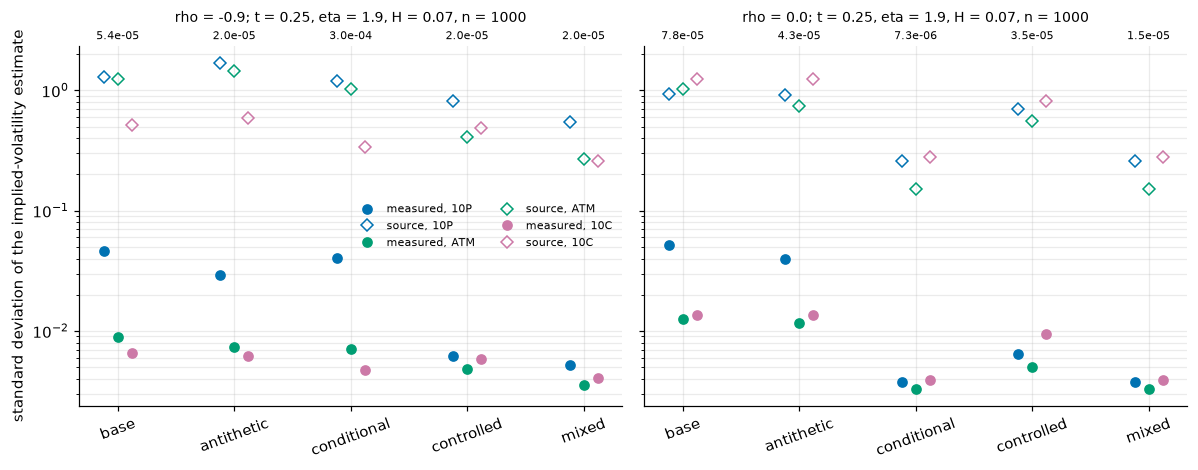

In [22]:
# Post-research figure: spread of the implied-volatility estimate by estimator, from figures/fig-1.3.csv
df13 = pd.read_csv("figures/fig-1.3.csv")
print(df13.groupby(["rho", "estimator"])[["sd_volpt", "tau_ms", "psi2"]].mean().round(6).to_string())
pp = df13.groupby(["rho", "estimator"])["psi2"].mean().unstack()[ORDER]
print("runtime-adjusted ratio base psi2 / estimator psi2 (above one means cheaper at equal accuracy):")
print((pp.div(pp["base"], axis=0) ** -1).round(2).to_string())
scol = {"10P": "#0072B2", "ATM": "#009E73", "10C": "#CC79A7"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, rho in zip(axes, sorted(df13["rho"].unique())):
    sub = df13[df13["rho"] == rho]
    for j, lab in enumerate(["10P", "ATM", "10C"]):
        s = sub[sub["strike_label"] == lab].set_index("estimator").loc[ORDER]
        xs_ = np.arange(len(ORDER)) + (j - 1) * 0.12
        ax.semilogy(xs_, s["sd_volpt"], "o", color=scol[lab], label=f"measured, {lab}")
        ax.semilogy(xs_, s["source_sd_volpt"], "D", mfc="none", color=scol[lab], label=f"source, {lab}")
    for i, m in enumerate(ORDER):
        ax.annotate(f"{pp.loc[rho, m]:.1e}", (i, 1.02), xycoords=("data", "axes fraction"), ha="center", fontsize=7)
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels(ORDER, rotation=20)
    ax.set_title(f"rho = {rho}; t = 0.25, eta = 1.9, H = 0.07, n = 1000", fontsize=9, pad=16)
    ax.grid(alpha=0.25, which="both")
axes[0].set_ylabel("standard deviation of the implied-volatility estimate")
axes[0].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

**How to read.** Filled dots are the measured standard deviations of the implied-volatility estimate and hollow diamonds are the values of Table 3 of the source, in the units each file states; lower is better and the order of the columns is the comparison, not the absolute level. The small number above each column is the runtime-adjusted measure, which includes cost.

**Interpretation.** On variance alone the ordering of the source is reproduced: the mixed estimator has the smallest spread at both correlations, and at zero correlation it equals the conditional estimator, because the control variable is constant there and the coefficient is zero. Cost changes the picture. The conditional and mixed estimators cost several times the base per estimate, so at equal accuracy the conditional estimator alone is not cheaper than the base at the strongly negative correlation, while the mixed estimator is, by a factor smaller than the fold figures of the source (see the printed ratios). Times here are fractions of a millisecond against about a hundred in the source, so such ratios depend on the implementation (derivation step 9). Negative result: antithetic variates are not a free gain. On independent samples the variance ratio is below one but within sampling noise of one, far from the reductions of the controlled and mixed estimators, and the source's own Table 3 has the antithetic spread above the base at the 10 delta put.

**Limits.** **Limits.** Table 3 of the source is stated in percentage points of implied volatility, while the file read by the figure states vol points; its grid of 24 time steps and its number of repetitions differ from the experiment of the source, so only the ordering of the estimators is compared and no numerical agreement is claimed. The source reports 20250 in the text and 20500 in a caption for the matched path count at zero correlation, an internal inconsistency, and its 13-fold and 34-fold claims depend on its own timings. Sobol numbers are not given in the source. The sample maximum used for the control makes the controlled and mixed estimators slightly biased (derivation step 6), and no trace quantifies that bias.

## Self-financing hedging with proportional costs

**Claim.** The terminal wealth of a hedger who is short one claim, receives a premium and trades a position $\delta$ with proportional costs is an exact accounting identity: premium plus trading gains minus total cost minus payoff. Three classical strategies sit on top of it: Black-Scholes delta, Leland-adjusted delta and the Whalley-Wilmott no-trade band. source: rhB-q2

> "$PL_T(Z, p_0, \delta) := -Z + p_0 + (\delta \cdot S)_T - C_T(\delta)$ ... where total cost up to maturity is $C_T(\delta) := \sum_{k=0}^n c_k(\delta_k - \delta_{k-1})$"  (rhB-q2, Eq 2.1; math delimiters added to the trace's typesetting)

> "$c_k(n) = \sum_{i=1}^d \varepsilon |n_i| S_k^i$"  (rhB-q2, Eq 5.7, proportional cost)

> "$h_{WW}$ scales as $\lambda^{1/3}$" and "$h_{WW}$ scales as $\gamma^{-1/3}$" and "$h_{WW}$ expands as $\Gamma_{BS}^{2/3}$"  (rhB-q4, Eq 40, Sec 2.6; the band is $h_{WW}(t,S)=\big(3\lambda\,\delta(t,T)\,S\,\Gamma_{BS}(t,S)^2/(2\gamma)\big)^{1/3}$)

> "None of the four sources provide or derive Leland's (1985) friction-adjusted volatility formula"  and  "This benchmark must be added as an external baseline design decision."  (rhB-q12, Part 2, Leland row)

**Derivation 1 (derived here): the ledger and the telescoping identity.** Zero interest rate, trades at $t_0,\dots,t_{N-1}$, position before $t_0$ equal to zero, $\Delta_i=\delta_i-\delta_{i-1}$ with $\delta_{-1}=0$, proportional cost rate $c\ge 0$ (a dimensionless fraction of the traded value).

1. Cash starts at the premium, $B_0=p_0$ (before the first trade). The trade $\Delta_i$ at $t_i$ costs $\Delta_i S_i + c|\Delta_i|S_i$, so $B_i=B_{i-1}-\Delta_iS_i-c|\Delta_i|S_i$. At $t_N$ the position $\delta_{N-1}$ is sold: $B_N=B_{N-1}+\delta_{N-1}S_N-c|\delta_{N-1}|S_N$. The short call settles for $(S_N-K)^+$, so wealth is $B_N-(S_N-K)^+$.
2. Summation by parts removes every cash term that is not a gain. Because $\delta_{-1}=0$ the boundary terms telescope:
$$-\sum_{i=0}^{N-1}(\delta_i-\delta_{i-1})S_i+\delta_{N-1}S_N=-\sum_{i=0}^{N-1}\delta_iS_i+\sum_{i=0}^{N-2}\delta_iS_{i+1}+\delta_{N-1}S_N=\sum_{i=0}^{N-1}\delta_i\,(S_{i+1}-S_i).$$
3. Hence
$$\text{wealth}=p_0+\sum_{i=0}^{N-1}\delta_i(S_{i+1}-S_i)-c\sum_{i=0}^{N-1}|\Delta_i|S_i-c\,|\delta_{N-1}|S_N-(S_N-K)^+ ,$$
gains minus costs minus payoff. No probabilistic argument was used: the identity holds path by path for any position array, even one that looks ahead. In floating point the discrepancy is of order $N\,\varepsilon_{\mathrm{mach}}\max|\delta S|$, far below the tolerance of the library contract.
4. Relation to the quoted Eq 2.1: its cost sum runs over $k=0,\dots,n$ with $c_k(\delta_k-\delta_{k-1})$; the term $k=n$ is the sale of the last position exactly when $\delta_n=0$. This is how the notebook reads it (the trace does not print $\delta_n$, so this is an inference), and it corresponds to the library switch `unwind=True`. With `unwind=False` the open position is only marked at $S_N$ and no final fee is charged.
5. Cost convention (design decision, not a source statement): the cost rate $c$ is a one-way rate per side, the trade is charged $c\,|\Delta|\,S$ on entry, on every rebalancing and on the final sale. Eq 5.7 writes the same quantity as $\varepsilon|n_i|S_k^i$, so $\varepsilon$ and $c$ play the same role. Whether a cost quoted by a source is one-way or round-trip is a convention that no trace settles here; Derivation 3 shows where it matters.

**Derivation 2 (derived here): Black-Scholes delta, gamma, vega and the discretisation error.** For a call with zero rate, $\tau=T-t$, $d_1=\dfrac{\ln(S/K)+\tfrac12\sigma^2\tau}{\sigma\sqrt\tau}$.

1. Delta is $\Delta=\Phi(d_1)$. Since $\partial d_1/\partial S=1/(S\sigma\sqrt\tau)$, gamma is $\Gamma=\dfrac{\varphi(d_1)}{S\sigma\sqrt\tau}$ and vega is $S\varphi(d_1)\sqrt\tau$. Dividing, $\text{vega}=\sigma\tau S^2\Gamma$, which is used below to cross-check two package functions that compute them separately.
2. Discrete hedging error (not given by any of the four sources; rhB-q7 Sec 3 (b) records that none reports a rate): over one step the replication error is $\tfrac12\Gamma S^2\big(\sigma^2h-(\Delta S/S)^2\big)$ with variance $\tfrac12\Gamma^2S^4\sigma^4h^2$, using $\operatorname{Var}Z^2=2$ for a standard normal $Z$. Summing $N=T/h$ nearly independent steps gives a standard deviation of order $N^{-1/2}$. The growth of $\Gamma$ near expiry changes the constant and slightly the exponent, so a fitted exponent need not equal $-\tfrac12$ exactly.

**Derivation 3 (derived here, heuristic): Leland's adjusted volatility and its cost convention.**

1. One rebalancing trades $|\Gamma|\,|\Delta S|$ shares. With $E|\Delta S|=\sigma S\sqrt{2h/\pi}$, the expected cost of a step is $c\,\sigma S^2\Gamma\sqrt{2h/\pi}$ for a one-way rate $c$ per side.
2. The gain from gamma over a step is $\tfrac12\Gamma S^2\sigma^2h$. Charging the expected cost to the writer and matching terms gives, with a round-trip rate $k$ equal to $2c$,
$$\sigma_L^2=\sigma^2\Big(1+\sqrt{\tfrac2\pi}\,\frac{k}{\sigma\sqrt h}\Big).$$
3. The library takes the number it is given as the $k$ of this formula (the quoted external formula has a single cost symbol $\lambda$). Called with the one-way cost $c$ it therefore applies $k=c$, whereas the heuristic of step 2 gives $k=2c$. The Leland baseline of this notebook is consequently under-adjusted relative to the heuristic: a conservative, not a definitive, Leland strategy. The sources do not give this factor.
4. Units: $c$ is a dimensionless rate and $\sigma\sqrt h$ is dimensionless, so $x=\sqrt{2/\pi}\,k/(\sigma\sqrt h)$ is dimensionless, and $1+\tfrac x2-\tfrac{x^2}8\le\sqrt{1+x}\le1+\tfrac x2$. The adjusted volatility is therefore an increase of roughly $x/2$ in relative terms, scale invariant under $(k,h)\mapsto(2k,4h)$, and equal to $\sigma$ at zero cost.

**Derivation 4 (derived here, heuristic): the Whalley-Wilmott half-width by a balance argument, and the band mechanics.**

1. The delta error $y$, measured in shares, diffuses with volatility $\sigma_y=\Gamma\sigma S$. With a band $[-h,h]$ the error is reflected at the walls. The cost rate is $\lambda S\,\sigma_y^2/(2h)$ (local time at the two walls). For an investor with exponential utility (risk aversion $\gamma$) the risk penalty is $\tfrac12\gamma S^2\sigma^2E[y^2]=\gamma S^2\sigma^2h^2/6$, since $y$ is uniform on the band.
2. Minimise $J(h)=A/h+Bh^2$ with $A=\lambda S\Gamma^2\sigma^2S^2/2$ and $B=\gamma S^2\sigma^2/6$. Then $h^3=A/(2B)=\dfrac{3\lambda S\Gamma^2}{2\gamma}$, which is the quoted Eq 40 with discount factor one. The exponents $\tfrac13$ in $\lambda$, $-\tfrac13$ in $\gamma$ and $\tfrac23$ in $\Gamma$ follow at once.
3. Units: $\lambda$ is dimensionless, $S\Gamma^2$ has units of one over price, and so does $\gamma$, so $h$ is dimensionless, a number of shares of the underlying.
4. Band mechanics: `apply_no_trade_band(prev, centre, h)` equals $\operatorname{clip}(\text{prev},\,\text{centre}-h,\,\text{centre}+h)$. It is idempotent, leaves a position inside the band unchanged (no trade), and moves a position outside to the nearest edge, the cheapest trade that restores the band. At zero cost $h=0$ and the policy is plain delta hedging.
5. This balance argument is optimal for exponential utility, not for a tail measure such as the conditional value at risk used in the next section.

In [23]:
from scipy.optimize import minimize_scalar
from rough_hedge.rbergomi import simulate_rbergomi
from rough_hedge.hedging import hedging_pnl, run_strategy, turnover
from rough_hedge.pricing import bs_call, bs_delta, bs_gamma, bs_vega
from rough_hedge.baselines import (bs_call_delta, bs_call_gamma, leland_sigma, ww_half_width,
                                   apply_no_trade_band, bs_delta_policy, leland_delta_policy, ww_policy)

SIG5, K5, N5, T5 = 0.2, 1.0, 30, 30 / 252      # volatility, strike, rebalancing dates, maturity in years
COST5, P0_5, GAM5 = 0.001, 0.02, 10.0          # one-way cost rate (10 bp), premium, risk aversion of the band
OKABE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]

# Black-Scholes market from the package simulator: eta = 0 and constant variance sigma^2
sim5 = simulate_rbergomi(20000, N5, T5, 0.1, 0.0, 0.0, SIG5 ** 2, rng=np.random.default_rng(5101))
S5 = sim5["S"]
print("INFO Black-Scholes sample:", S5.shape, "max |V - sigma^2| =", float(np.abs(sim5["V"] - SIG5 ** 2).max()))

INFO Black-Scholes sample: (20000, 31) max |V - sigma^2| = 0.0


INFO library total cost 0.002430, running ledger total 0.002430


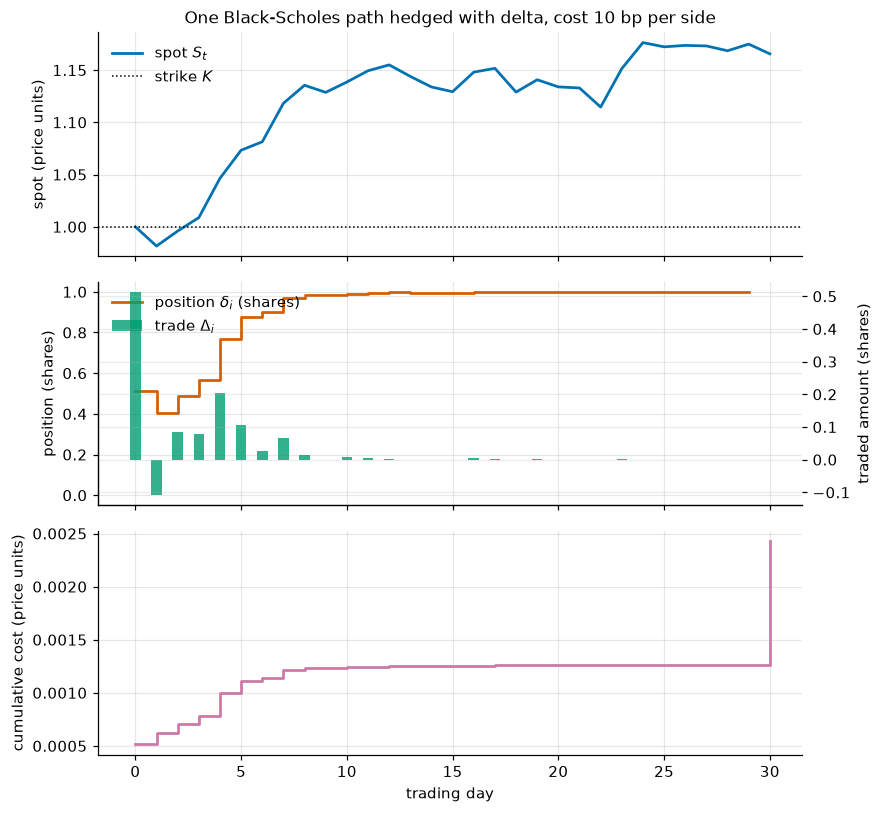

In [24]:
# Pre-research figure: one hedged path, spot, position with traded amount, cumulative cost
sim1 = simulate_rbergomi(1, N5, T5, 0.1, 0.0, 0.0, SIG5 ** 2, rng=np.random.default_rng(5102))
S1p = sim1["S"]
r1 = run_strategy(S1p, bs_delta_policy(K5, SIG5, T5, N5), K5, COST5, p0=P0_5)
pos1 = r1.positions[0]
trade1 = np.diff(np.concatenate([[0.0], pos1]))
fee1 = COST5 * np.abs(trade1) * S1p[0, :-1]
cum1 = np.concatenate([np.cumsum(fee1), [fee1.sum() + COST5 * abs(pos1[-1]) * S1p[0, -1]]])
day = np.arange(N5 + 1) * 252 * T5 / N5

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(8, 7.5))
ax[0].plot(day, S1p[0], color=OKABE[0], lw=1.8, label="spot $S_t$")
ax[0].axhline(K5, color=OKABE[6], ls=":", lw=1, label="strike $K$")
ax[0].set_ylabel("spot (price units)"); ax[0].legend(loc="upper left")
ax[0].set_title("One Black-Scholes path hedged with delta, cost 10 bp per side")
ax[1].step(day[:-1], pos1, where="post", color=OKABE[1], lw=1.8, label="position $\\delta_i$ (shares)")
ax[1].set_ylabel("position (shares)"); ax[1].set_ylim(-0.05, 1.05)
bx = ax[1].twinx()
bx.bar(day[:-1], trade1, width=0.5, color=OKABE[2], alpha=0.8, label="trade $\\Delta_i$")
bx.set_ylabel("traded amount (shares)")
h1, l1 = ax[1].get_legend_handles_labels(); h2, l2 = bx.get_legend_handles_labels()
ax[1].legend(h1 + h2, l1 + l2, loc="upper left")
ax[2].step(day, cum1, where="post", color=OKABE[3], lw=1.8)
ax[2].set_ylabel("cumulative cost (price units)"); ax[2].set_xlabel("trading day")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
print(f"INFO library total cost {r1.costs[0]:.6f}, running ledger total {cum1[-1]:.6f}")
plt.show()

**How to read.** The top panel is the spot with the strike, the middle one the held position (line) and the amount traded at each date (bars), and the bottom one the running cost. Costs rise in steps exactly where the position changes, and the position follows the option delta along the spot path.

                        max |pnl - ledger|  max |pnl - (gains - costs - payoff + p0)|
bs_delta, unwind=True         9.992007e-16                               4.510281e-17
bs_delta, unwind=False        9.992007e-16                               4.510281e-17
random, unwind=True           8.378714e-16                               4.163336e-17
random, unwind=False          8.378714e-16                               4.163336e-17


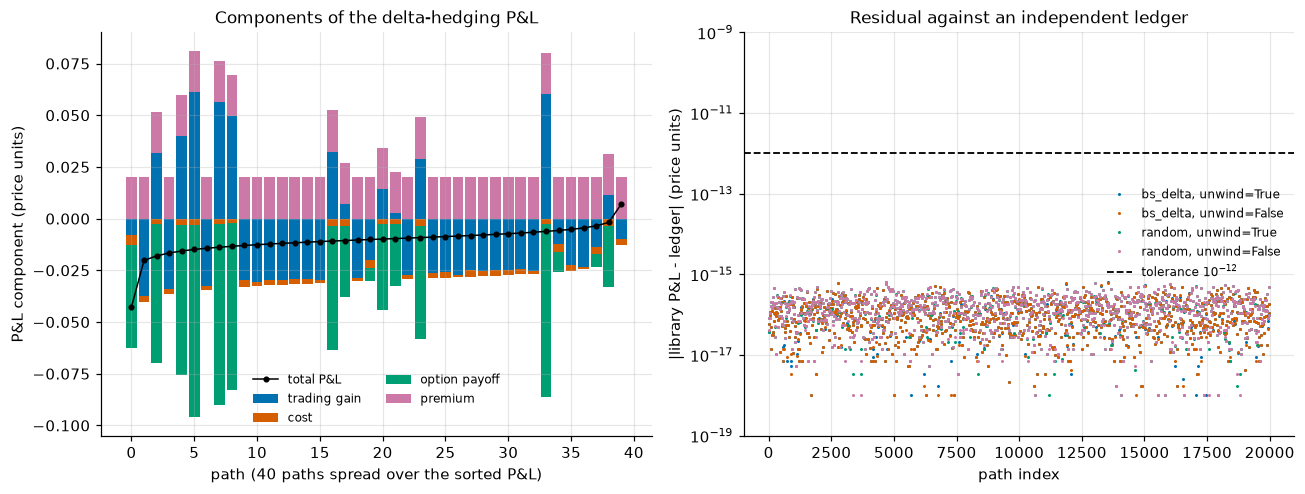

In [25]:
# Mid-research figure: the P&L decomposition is an identity on every path
rng_m = np.random.default_rng(5103)
delta5 = run_strategy(S5, bs_delta_policy(K5, SIG5, T5, N5), K5, COST5, p0=P0_5)
cases = {"bs_delta": delta5.positions, "random": rng_m.uniform(0.0, 1.0, delta5.positions.shape)}
res = {}
for nm, pos in cases.items():
    for unw in (True, False):
        trades = np.diff(np.concatenate([np.zeros((pos.shape[0], 1)), pos], axis=1), axis=1)      # Delta_i
        fees = COST5 * np.abs(trades) * S5[:, :-1]
        cash = P0_5 - np.cumsum(trades * S5[:, :-1] + fees, axis=1)[:, -1]                          # cash after the last trade
        cash = cash + pos[:, -1] * S5[:, -1] - (COST5 * np.abs(pos[:, -1]) * S5[:, -1] if unw else 0.0)
        wealth = cash - np.maximum(S5[:, -1] - K5, 0.0)
        lib = hedging_pnl(S5, pos, K5, COST5, p0=P0_5, unwind=unw)
        res[(nm, unw)] = (np.abs(lib.pnl - wealth), lib, wealth)

lib0 = res[("bs_delta", True)][1]
order = np.argsort(lib0.pnl)
idx = order[np.linspace(0, order.size - 1, 40).astype(int)]
comp = [("trading gain", lib0.gains[idx]), ("cost", -lib0.costs[idx]), ("option payoff", -lib0.payoff[idx]),
        ("premium", np.full(idx.size, P0_5))]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
up, dn = np.zeros(idx.size), np.zeros(idx.size)
xs = np.arange(idx.size)
for k, (lab, v) in enumerate(comp):
    ax[0].bar(xs, v, bottom=np.where(v >= 0, up, dn), color=OKABE[k], width=0.85, label=lab)
    up = up + np.where(v >= 0, v, 0.0); dn = dn + np.where(v < 0, v, 0.0)
ax[0].plot(xs, lib0.pnl[idx], color=OKABE[6], marker=".", lw=1, label="total P&L")
ax[0].set_xlabel("path (40 paths spread over the sorted P&L)"); ax[0].set_ylabel("P&L component (price units)")
ax[0].set_title("Components of the delta-hedging P&L"); ax[0].legend(fontsize=8, ncol=2)
for k, ((nm, unw), (r, _, _)) in enumerate(res.items()):
    ax[1].plot(np.arange(r.size)[::20], np.maximum(r, 1e-18)[::20], ".", ms=2, color=OKABE[k],
               label=f"{nm}, unwind={unw}", rasterized=True)
ax[1].axhline(1e-12, color=OKABE[6], ls="--", lw=1.2, label="tolerance $10^{-12}$")
ax[1].set_yscale("log"); ax[1].set_ylim(1e-19, 1e-9)
ax[1].set_xlabel("path index"); ax[1].set_ylabel("|library P&L - ledger| (price units)")
ax[1].set_title("Residual against an independent ledger"); ax[1].legend(fontsize=8, loc="center right")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
tabr = pd.DataFrame({f"{k[0]}, unwind={k[1]}": [float(v[0].max()), float(np.abs(v[1].gains - v[1].costs - v[1].payoff + P0_5 - v[1].pnl).max())]
                     for k, v in res.items()}, index=["max |pnl - ledger|", "max |pnl - (gains - costs - payoff + p0)|"]).T
print(tabr.to_string())
plt.show()

**How to read.** The left panel shows where the profit and loss of each path comes from: trading gain, cost, option payoff and premium, with the total as a line. The right panel shows how far the library total is from a ledger recomputed independently by cash accounting, for the delta policy and for random positions, with and without the final sale. A pass means every point stays at rounding level, below the dashed tolerance; the log axis is clipped from below, so a point on the floor is an exact match.

In [26]:
# SF-1: ledger identity and turnover
obs = max(float(v[0].max()) for v in res.values())
CHECK("SF-1 ledger identity, delta and random positions, unwind on and off: max |pnl - ledger|", obs <= 1e-12, obs, "<= 1e-12")
tov_err = 0.0
for nm, pos in cases.items():
    for unw in (True, False):
        pad = np.concatenate([np.zeros((pos.shape[0], 1)), pos] + ([np.zeros((pos.shape[0], 1))] if unw else []), axis=1)
        tov_err = max(tov_err, float(np.abs(turnover(pos, unwind=unw) - np.abs(np.diff(pad, axis=1)).sum(axis=1)).max()))
CHECK("SF-1b turnover equals the sum of absolute position changes incl. entry and exit", tov_err <= 1e-12, tov_err, "<= 1e-12")

# SF-2: Black-Scholes derivatives against finite differences of the package price
Sg, tau, hfd = np.linspace(0.8, 1.2, 81), 0.1, 1e-4
d_fd = (bs_call(Sg + hfd, K5, SIG5, tau) - bs_call(Sg - hfd, K5, SIG5, tau)) / (2 * hfd)
gam = lambda s: bs_call_gamma(s, K5, SIG5, tau)
g_fd = (bs_call_delta(Sg + hfd, K5, SIG5, tau) - bs_call_delta(Sg - hfd, K5, SIG5, tau)) / (2 * hfd)
hh = 1e-3
dgam = np.abs((gam(Sg + hh) - gam(Sg - hh)) / (2 * hh)).max()
d2gam = np.abs((gam(Sg + hh) - 2 * gam(Sg) + gam(Sg - hh)) / hh ** 2).max()
obs = float(np.abs(d_fd - bs_call_delta(Sg, K5, SIG5, tau)).max()); tol = 2 * hfd ** 2 / 6 * dgam + 1e-9
CHECK("SF-2a central difference of bs_call equals bs_call_delta (bound from third derivative)", obs <= tol, obs, f"<= {tol:.3g}")
obs = float(np.abs(g_fd - gam(Sg)).max()); tol = 2 * hfd ** 2 / 6 * d2gam + 1e-9
CHECK("SF-2b central difference of bs_call_delta equals bs_call_gamma (bound from fourth derivative)", obs <= tol, obs, f"<= {tol:.3g}")
obs = float(np.abs(bs_vega(Sg, K5, SIG5, tau) - SIG5 * tau * Sg ** 2 * gam(Sg)).max())
CHECK("SF-2c vega equals sigma tau S^2 gamma", obs <= 1e-12, obs, "<= 1e-12")
obs = float(np.abs(bs_delta(Sg, K5, SIG5, tau) - bs_call_delta(Sg, K5, SIG5, tau)).max())
CHECK("SF-2d pricing.bs_delta equals baselines.bs_call_delta", obs <= 1e-12, obs, "<= 1e-12")

# SF-3: Leland adjustment
dt5 = T5 / N5
obs = abs(leland_sigma(SIG5, 0.0, dt5) - SIG5)
CHECK("SF-3a Leland sigma equals sigma at zero cost", obs <= 1e-15, obs, "<= 1e-15")
xL = np.sqrt(2 / np.pi) * COST5 / (SIG5 * np.sqrt(dt5))
ratioL = leland_sigma(SIG5, COST5, dt5) / SIG5
obs = abs(ratioL - 1 - xL / 2)
CHECK("SF-3b |sigma_L/sigma - 1 - x/2| within x^2/8", obs <= xL ** 2 / 8 + 1e-15, obs, f"<= {xL ** 2 / 8:.3g}")
obs = abs(leland_sigma(SIG5, 2 * COST5, 4 * dt5) - leland_sigma(SIG5, COST5, dt5))
CHECK("SF-3c scale invariance (2c, 4dt) versus (c, dt)", obs <= 1e-14, obs, "<= 1e-14")
print(f"INFO Leland ratio sigma_L/sigma = {ratioL:.4f} at cost {COST5} and dt = T/{N5}; x = {xL:.4f}")

# SF-4: Whalley-Wilmott band
Gam = float(np.ravel(bs_call_gamma(1.0, K5, SIG5, 0.1))[0]); lam = 0.001   # scalar input returns a length-one array
A_ = lam * 1.0 * Gam ** 2 * SIG5 ** 2 / 2; B_ = GAM5 * SIG5 ** 2 / 6
opt = minimize_scalar(lambda h: A_ / h + B_ * h ** 2, bounds=(1e-6, 1.0), method="bounded", options={"xatol": 1e-13})
hw = float(np.ravel(ww_half_width(1.0, Gam, lam, GAM5))[0])
obs = abs(opt.x - hw)
CHECK("SF-4a numerical minimiser of A/h + B h^2 equals ww_half_width", obs <= 1e-6 * hw, obs, f"<= {1e-6 * hw:.3g}")
rat = [float(np.ravel(ww_half_width(1.0, g_, c_, a_))[0]) / hw for g_, c_, a_ in ((Gam, 8 * lam, GAM5), (Gam, lam, 8 * GAM5), (8 * Gam, lam, GAM5))]
obs = max(abs(rat[0] / 2 - 1), abs(rat[1] * 2 - 1), abs(rat[2] / 4 - 1))
CHECK("SF-4b scalings: cost x8 gives 2, risk aversion x8 gives 1/2, gamma x8 gives 4", obs <= 1e-12, obs, "<= 1e-12")
p_bs0 = run_strategy(S5, bs_delta_policy(K5, SIG5, T5, N5), K5, 0.0).positions
p_ww0 = run_strategy(S5, ww_policy(K5, SIG5, T5, N5, 0.0, GAM5), K5, 0.0).positions
obs = float(np.abs(p_bs0 - p_ww0).max())
CHECK("SF-4c at zero cost the band policy equals the delta policy", obs <= 1e-12, obs, "<= 1e-12")
ww5 = run_strategy(S5, ww_policy(K5, SIG5, T5, N5, COST5, GAM5), K5, COST5, p0=P0_5)
dtv = turnover(delta5.positions) - turnover(ww5.positions)
zt = float(dtv.mean() / (dtv.std(ddof=1) / np.sqrt(dtv.size)))
CHECK("SF-4d band turnover below delta turnover (paired z)", zt >= 4, zt, ">= 4")
print(f"INFO mean turnover delta {turnover(delta5.positions).mean():.3f}, band {turnover(ww5.positions).mean():.3f}; ratio band/delta {turnover(ww5.positions).mean() / turnover(delta5.positions).mean():.3f}")

# SF-5: discretisation-error exponent at zero cost
Ns = np.array([15, 30, 60, 120]); sds = []
for n in Ns:
    s = simulate_rbergomi(20000, int(n), T5, 0.1, 0.0, 0.0, SIG5 ** 2, rng=np.random.default_rng(5200 + int(n)))["S"]
    sds.append(run_strategy(s, bs_delta_policy(K5, SIG5, T5, int(n)), K5, 0.0).pnl.std(ddof=1))
lx = np.log(Ns); slope = float(np.polyfit(lx, np.log(sds), 1)[0])
se_slope = float(np.sqrt(1 / (2 * 19999)) / np.sqrt(((lx - lx.mean()) ** 2).sum()))
CHECK("SF-5 slope of log std(P&L) on log N against -1/2 (design allowance 0.06)", abs(slope + 0.5) <= 0.06, slope, "|slope + 1/2| <= 0.06")
print(f"INFO slope {slope:.3f}, sampling standard error {se_slope:.3f}, distance from -1/2 in standard errors {abs(slope + 0.5) / se_slope:.1f}")

# SF-4e: the stored figure data at zero cost
dfc = pd.read_csv("figures/fig-1.5.csv")
z0 = dfc[dfc.cost_bp == 0].pivot_table(index="bin_left", columns="strategy", values="density")
obs = float((z0.max(axis=1) - z0.min(axis=1)).max())
CHECK("SF-4e fig-1.5 data: at zero cost the three loss densities coincide", obs <= 1e-9, obs, "<= 1e-9")

CHECK SF-1 ledger identity, delta and random positions, unwind on and off: max |pnl - ledger| | observed=9.992e-16 | expected=<= 1e-12 | PASS
CHECK SF-1b turnover equals the sum of absolute position changes incl. entry and exit | observed=7.105e-15 | expected=<= 1e-12 | PASS
CHECK SF-2a central difference of bs_call equals bs_call_delta (bound from third derivative) | observed=1.085e-07 | expected=<= 2.18e-07 | PASS
CHECK SF-2b central difference of bs_call_delta equals bs_call_gamma (bound from fourth derivative) | observed=2.687e-06 | expected=<= 5.37e-06 | PASS
CHECK SF-2c vega equals sigma tau S^2 gamma | observed=5.551e-17 | expected=<= 1e-12 | PASS
CHECK SF-2d pricing.bs_delta equals baselines.bs_call_delta | observed=2.22e-16 | expected=<= 1e-12 | PASS
CHECK SF-3a Leland sigma equals sigma at zero cost | observed=0 | expected=<= 1e-15 | PASS
CHECK SF-3b |sigma_L/sigma - 1 - x/2| within x^2/8 | observed=0.0004861 | expected=<= 0.000501 | PASS
CHECK SF-3c scale invariance (2c, 4dt

CHECK SF-4c at zero cost the band policy equals the delta policy | observed=0 | expected=<= 1e-12 | PASS
CHECK SF-4d band turnover below delta turnover (paired z) | observed=294.2 | expected=>= 4 | PASS
INFO mean turnover delta 2.720, band 1.398; ratio band/delta 0.514


CHECK SF-5 slope of log std(P&L) on log N against -1/2 (design allowance 0.06) | observed=-0.4878 | expected=|slope + 1/2| <= 0.06 | PASS
INFO slope -0.488, sampling standard error 0.003, distance from -1/2 in standard errors 3.8
CHECK SF-4e fig-1.5 data: at zero cost the three loss densities coincide | observed=0 | expected=<= 1e-9 | PASS


                      cvar95  mean_turnover
strategy     cost_bp                       
bs_delta     0.0      0.0102         2.7114
             10.0     0.0138         2.7114
leland_delta 0.0      0.0102         2.7114
             10.0     0.0134         2.6863
ww_band      0.0      0.0102         2.7114
             10.0     0.0205         1.3943
INFO provenance: [{'run_id': 'r1-3-fig', 'seed': 101, 'config_hash': '0d67cc9d013d0fef', 'n_paths': 20000}]
OBSERVED at 10 bp, strategies ordered by cvar95 (low to high): ['leland_delta', 'bs_delta', 'ww_band']
OBSERVED at 10 bp, band turnover over delta turnover: 0.514


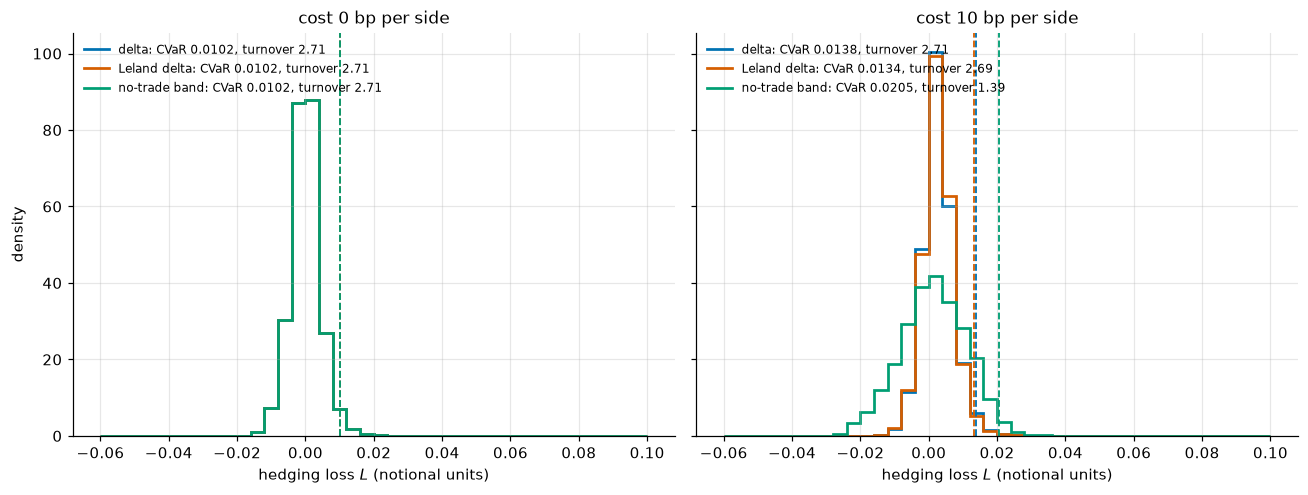

In [27]:
# Post-research figure: loss distributions of the three strategies, from figures/fig-1.5.csv
df = pd.read_csv("figures/fig-1.5.csv")
tab = df.groupby(["strategy", "cost_bp"])[["cvar95", "mean_turnover"]].first()
print(tab.round(4).to_string())
print("INFO provenance:", df[["run_id", "seed", "config_hash", "n_paths"]].drop_duplicates().to_dict("records"))
c10 = tab.xs(10.0, level="cost_bp")
print("OBSERVED at 10 bp, strategies ordered by cvar95 (low to high):", list(c10["cvar95"].sort_values().index))
print("OBSERVED at 10 bp, band turnover over delta turnover:", round(float(c10.loc["ww_band", "mean_turnover"] / c10.loc["bs_delta", "mean_turnover"]), 3))
names = {"bs_delta": "delta", "leland_delta": "Leland delta", "ww_band": "no-trade band"}
cols = {"bs_delta": OKABE[0], "leland_delta": OKABE[1], "ww_band": OKABE[2]}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for a, cb in zip(ax, (0.0, 10.0)):
    for st in ("bs_delta", "leland_delta", "ww_band"):
        d = df[(df.strategy == st) & (df.cost_bp == cb)].sort_values("bin_left")
        edges = np.append(d.bin_left.to_numpy(), d.bin_right.iloc[-1])
        a.stairs(d.density.to_numpy(), edges, color=cols[st], lw=1.8,
                 label=f"{names[st]}: CVaR {d.cvar95.iloc[0]:.4f}, turnover {d.mean_turnover.iloc[0]:.2f}")
        a.axvline(d.cvar95.iloc[0], color=cols[st], ls="--", lw=1.2)
    a.set_title(f"cost {cb:g} bp per side"); a.set_xlabel("hedging loss $L$ (notional units)"); a.grid(alpha=0.3)
    a.legend(fontsize=8, loc="upper left")
ax[0].set_ylabel("density")
fig.tight_layout()
plt.show()

**How to read.** Each curve is the distribution of the terminal hedging loss over the same simulated paths, and the dashed line of the same colour marks the mean of the worst five percent of outcomes. The legend gives that tail mean and the mean turnover. Differences between strategies live in the right tail and in the turnover; at zero cost the curves lie on top of each other.

**Interpretation.** The identity makes the P&L bookkeeping exact, so differences between the curves are strategy effects and not accounting artefacts. At zero cost delta, Leland and the band coincide, as the checks of the adjusted volatility and of the zero-cost band demand. The Leland adjustment raises the hedging volatility by a few percent at these parameters and moves the loss distribution and the turnover only slightly. The band trades roughly half as much as plain delta (printed turnover column).

*Negative result, observed here and not supported by a source.* At the positive cost the printed ordering puts the band strategy highest in tail loss (conditional value at risk at level $0.95$) of the three, although it trades least, so fewer trades do not mean a lower tail risk. The band of Eq 40 is optimal for exponential utility (rhB-q4 Sec 1), not for a tail measure, and its risk aversion was not tuned. The same print shows the Leland strategy below plain delta in tail loss, a small difference for which no uncertainty is available from the stored data.

*Second surprise.* The fitted discretisation exponent is not exactly $-\tfrac12$: the informational line prints the distance in standard errors, a visible higher-order effect of the growing gamma near expiry (Derivation 2).

**Limits.** rhB-q7 Sec 3: no source reports zero-cost Black-Scholes convergence of a learned hedge, a discretisation rate of order $N^{-1/2}$ (Derivation 2 is derived here and the fit is informational), seeds or confidence intervals. rhB-q2 and rhB-q7 report the cost asymptotic $p_\varepsilon-p_0=O(\varepsilon^{2/3})$ with empirical slopes from single runs and no uncertainty, which this notebook does not reproduce. rhB-q4 Sec 5: the band results concern a constant-volatility market with call and spread payoffs, and its best tail result is among deep-hedging architectures, not against delta or Leland. Neither deep-hedging source combines rough volatility with proportional costs (rhB-q2 Sec 4). The Leland formula is external (rhB-q12), and the one-way versus round-trip factor of Derivation 3 is settled by no trace. The figure data of the post figure come from one stored run (single seed): the ordering of strategies is a statement about that run, with no standard error attached.

## Risk measures for training: convex, cash-invariant, differentiable

**Claim.** A convex risk measure is monotone, convex and cash-invariant. The conditional value at risk and the entropic risk are both of this type; the conditional value at risk has a variational form with an auxiliary variable that makes it usable as a training loss. source: rhB-q2

> "(1) Monotone decreasing: if $X_1 \ge X_2$ then $\rho(X_1) \le \rho(X_2)$" ... "(3) Cash-Invariant: $\rho(X + c) = \rho(X) - c$ for $c \in \mathbb{R}$"  (rhB-q2, Definition 3.1; markdown emphasis removed)

> "Example 3.9. Let $\alpha \in (0, 1)$ and set $\ell(x) := \frac{1}{1-\alpha} \max(x, 0)$. The associated risk measure (3.5) is called average value at risk at level $1 - \alpha$ ... or also conditional value at risk or expected shortfall."  (rhB-q2, Example 3.9)

> "$\rho(X) = \frac{1}{\lambda} \log \mathbb{E}[\exp(-\lambda X)]$ (Eq. 3.4)" and "$\rho(X) := \frac{1}{1-\alpha} \int_0^{1-\alpha} \text{VaR}_\gamma(X)d\gamma$ (Eq. 5.1 / Ex. 3.9)"  (rhB-q12, Part 1)

> "Combining this with the Rockafellar-Uryasev (2000) auxiliary variable $v$ yields the differentiable training loss"  (rhB-q12, Part 2, first row, status DERIVABLE FROM SOURCES)

**Conventions and what the sources do not say (derived here).** The Rockafellar-Uryasev statement is not quoted in any trace: rhB-q12 only marks it derivable, so Derivation 1 proves it. Losses are $L=-\mathrm{PnL}$ and the package argument `alpha` is the quantile level, so that
$$\mathrm{CVaR}_\alpha(L)=\frac1{1-\alpha}\int_\alpha^1 q_u(L)\,du,$$
with $q_u$ the quantile function of $L$. Buehler's Eq 5.1 names the same measure by the tail mass $1-\alpha$ and integrates $\mathrm{VaR}_\gamma(X)$ of the P&L over $\gamma\in(0,1-\alpha)$; with $X=-L$ and the substitution $u=1-\gamma$ this is the formula above, so the two differ only in naming. `cvar_*` take losses, `entropic_risk` takes P&L, and $\rho(X)=\mathrm{CVaR}_\alpha(-X)$ turns a P&L into a risk number. Convexity in Definition 3.1 is printed with the range of the mixing weight garbled in the trace; it is read as: for $\lambda$ between zero and one, $\rho(\lambda X_1+(1-\lambda)X_2)\le\lambda\rho(X_1)+(1-\lambda)\rho(X_2)$.

**Derivation 1 (derived here): the Rockafellar-Uryasev representation.** Let $L$ be a loss with cdf $F_L$ and level $\alpha\in[0,1)$. Define $F(v)=v+\dfrac{E[(L-v)^+]}{1-\alpha}$.

1. $v\mapsto E[(L-v)^+]$ is convex, as an expectation of convex functions, so $F$ is convex.
2. The right derivative of $E[(L-v)^+]$ is $-P(L>v)$, so $F'_+(v)=1-\dfrac{P(L>v)}{1-\alpha}=\dfrac{F_L(v)-\alpha}{1-\alpha}$ and, from the left, $F'_-(v)=\dfrac{F_L(v^-)-\alpha}{1-\alpha}$.
3. A convex function is minimised where $F'_-(v)\le0\le F'_+(v)$, that is $F_L(v^-)\le\alpha\le F_L(v)$: exactly when $v$ is an $\alpha$-quantile. The set of minimisers is the interval between the lower and the upper quantile, and the lower quantile (`value_at_risk`) is one of them.
4. Value at the minimiser: write $L=q_U$ with $U$ uniform. Then $(q_U-q_\alpha)^+=(q_U-q_\alpha)\mathbf 1_{U>\alpha}$ almost surely, so $E[(L-q_\alpha)^+]=\int_\alpha^1(q_u-q_\alpha)\,du$ and
$$F(q_\alpha)=q_\alpha+\frac1{1-\alpha}\int_\alpha^1(q_u-q_\alpha)\,du=\frac1{1-\alpha}\int_\alpha^1q_u\,du=\mathrm{CVaR}_\alpha(L),$$
so $\mathrm{CVaR}_\alpha(L)=\min_v\{v+E[(L-v)^+]/(1-\alpha)\}$ with minimiser at the value at risk.
5. Axioms follow from the representation. The map $(L,v)\mapsto v+E(L-v)^+/(1-\alpha)$ is jointly convex, and a partial minimum of a jointly convex function is convex in $L$. It is monotone because $(L-v)^+$ is nondecreasing in $L$. Cash: $F_{L+c}(v+c)=F_L(v)+c$, so $\mathrm{CVaR}(L+c)=\mathrm{CVaR}(L)+c$; for a P&L $X=-L$ this reads $\rho(X+c)=\rho(X)-c$, the cash invariance of Definition 3.1. Positive homogeneity: $\mathrm{CVaR}(sL)=s\,\mathrm{CVaR}(L)$ for $s>0$.

**Derivation 2 (derived here): the sample version and why the training loss is differentiable almost everywhere.**

1. With sorted losses $L_{(1)}\le\dots\le L_{(n)}$ and $k=\lceil n\alpha\rceil$, the sample objective $F_n(v)=v+\frac1{n(1-\alpha)}\sum_i(L_i-v)^+$ is piecewise linear and convex with kinks at the sample points. A minimiser is $L_{(k)}$ (`value_at_risk`) and the minimum is $\sum_iw_iL_{(i)}$ with $w_i=\dfrac1{n(1-\alpha)}$ for $i>k$, $w_k=\dfrac{k-n\alpha}{n(1-\alpha)}$ and $w_i=0$ below: the interval-overlap weights of `cvar_tail_mean`. Because $F_n$ is linear between kinks, its minimum over the sample points equals its exact minimum, which gives an independent numerical check.
2. The weights sum to one: $\dfrac{(n-k)+(k-n\alpha)}{n(1-\alpha)}=1$.
3. $\mathrm{CVaR}_n=\sum_iw_iL_{(i)}$ is piecewise linear in $(L_1,\dots,L_n)$, with $\partial/\partial L_i=w_{\mathrm{rank}(i)}$ wherever the ordering has no ties. For continuous laws ties form a Lebesgue null set, so the objective is differentiable almost everywhere and its gradient is the weight vector (an envelope argument: the minimiser $v$ does not contribute to the first-order variation). With $L_i=L_i(\theta)$ the chain rule gives the training gradient. Where a tie or the boundary rank occurs only a one-sided derivative exists, which is why the statement is almost everywhere.
4. Cash invariance gives the practical consequence: adding the premium $p_0$ shifts the risk one-for-one and leaves every gradient with respect to $\theta$ unchanged.

**Derivation 3 (derived here): entropic risk.** For a P&L $X$ and $\gamma>0$, $\rho_\gamma(X)=\frac1\gamma\log E\,e^{-\gamma X}$.

1. Cash invariance: $\log E\,e^{-\gamma(X+c)}=\log E\,e^{-\gamma X}-\gamma c$, hence $\rho_\gamma(X+c)=\rho_\gamma(X)-c$. Monotone: $e^{-\gamma x}$ is decreasing in $x$.
2. Convex, by Hölder's inequality: $E\,e^{-\gamma(\lambda X_1+(1-\lambda)X_2)}\le(E\,e^{-\gamma X_1})^{\lambda}(E\,e^{-\gamma X_2})^{1-\lambda}$, then take $\frac1\gamma\log$.
3. Gradient with respect to the sample entries: $\partial\rho_\gamma/\partial x_i=-\dfrac{e^{-\gamma x_i}}{\sum_je^{-\gamma x_j}}=-\operatorname{softmax}(-\gamma x)_i$, smooth everywhere, in contrast with the weights of the conditional value at risk that jump at the quantile.
4. Gaussian closed forms. For $X\sim N(\mu,s^2)$ the moment generating function gives $\rho_\gamma(X)=-\mu+\gamma s^2/2$; for $L\sim N(0,1)$, $\mathrm{CVaR}_\alpha=\varphi(\Phi^{-1}(\alpha))/(1-\alpha)$. For small $\gamma$, $\rho_\gamma\approx-EX+\frac\gamma2\operatorname{Var}X$, and for large $\gamma$ it approaches the worst case, so $\gamma$ interpolates between mean and worst case, whereas the conditional value at risk looks only at the upper tail and gives zero weight below the quantile.
5. Monte Carlo uncertainty. The Rockafellar-Uryasev estimator is the sample mean of $v^*+(L_i-v^*)^+/(1-\alpha)$ at the (approximately) optimal $v^*$ and is first-order insensitive to $v$, so its standard error is approximately the standard deviation of the summands over $\sqrt n$. At $\alpha=0.95$ only one twentieth of the sample drives the tail part, so this standard error exceeds that of a plain mean. The entropic estimator has the delta-method standard error $\operatorname{sd}(e^{-\gamma x})/(\gamma\,\overline{e^{-\gamma x}}\sqrt n)$.

In [28]:
from scipy.stats import norm
from rough_hedge.rbergomi import simulate_rbergomi
from rough_hedge.hedging import run_strategy
from rough_hedge.pricing import bs_call
from rough_hedge.baselines import bs_delta_policy, ww_policy
from rough_hedge.risk import cvar_tail_mean, cvar_ru, ru_objective, value_at_risk, entropic_risk

SIG6, K6, N6, T6, COST6, ALPHA6 = 0.2, 1.0, 30, 30 / 252, 0.001, 0.95
OKABE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]
P6 = float(np.ravel(bs_call(1.0, K6, SIG6, T6))[0])            # Black-Scholes premium
sim6 = simulate_rbergomi(20000, N6, T6, 0.1, 0.0, 0.0, SIG6 ** 2, rng=np.random.default_rng(6101))
S6 = sim6["S"]
res6 = run_strategy(S6, bs_delta_policy(K6, SIG6, T6, N6), K6, COST6, p0=P6)
L6 = -res6.pnl                                                   # terminal hedging loss, delta policy, cost 10 bp
print("INFO loss sample:", L6.shape, "mean", round(float(L6.mean()), 5), "sd", round(float(L6.std()), 5))

INFO loss sample: (20000,) mean 0.00276 sd 0.00451


         mean    VaR95   CVaR95
loss  0.00276  0.01064  0.01364
OBSERVED ordering mean < VaR < CVaR: True


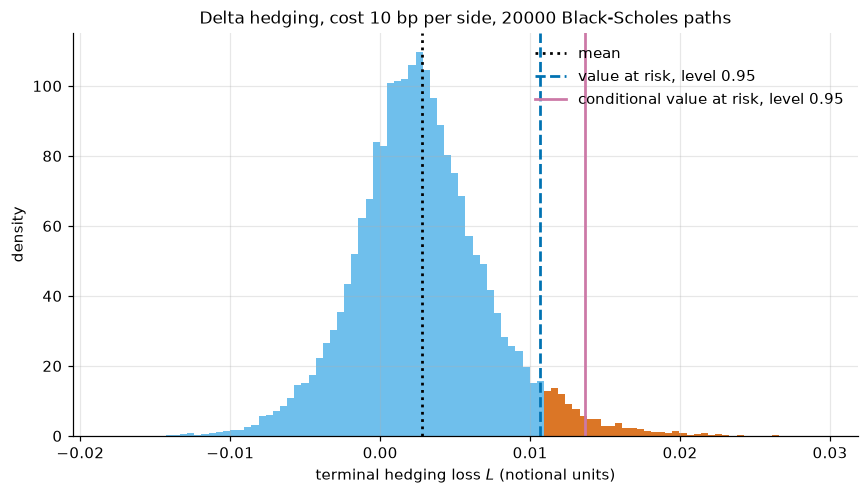

In [29]:
# Pre-research figure: the hedging-loss distribution with its mean, value at risk and conditional value at risk
m6, v6, c6 = float(L6.mean()), value_at_risk(L6, ALPHA6), cvar_tail_mean(L6, ALPHA6)
print(pd.DataFrame({"mean": [m6], "VaR95": [v6], "CVaR95": [c6]}, index=["loss"]).round(5).to_string())
print("OBSERVED ordering mean < VaR < CVaR:", bool(m6 < v6 < c6))
fig, ax = plt.subplots(figsize=(8, 4.6))
cnt, edges, patches = ax.hist(L6, bins=100, density=True, color=OKABE[5], alpha=0.85)
for p, lo in zip(patches, edges[:-1]):
    if lo >= v6:
        p.set_facecolor(OKABE[1])
ax.axvline(m6, color=OKABE[6], ls=":", lw=1.8, label="mean")
ax.axvline(v6, color=OKABE[0], ls="--", lw=1.8, label="value at risk, level 0.95")
ax.axvline(c6, color=OKABE[3], ls="-", lw=1.8, label="conditional value at risk, level 0.95")
ax.set_xlabel("terminal hedging loss $L$ (notional units)"); ax.set_ylabel("density")
ax.set_title("Delta hedging, cost 10 bp per side, 20000 Black-Scholes paths"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**How to read.** The histogram is the loss over many paths and the shaded part is the tail beyond the value at risk. The conditional value at risk is the average of the shaded part and so lies further right than the value at risk, which itself lies right of the mean.

grid minimiser 0.01063 versus value_at_risk 0.01064; grid minimum 0.01364 versus cvar_tail_mean 0.01364


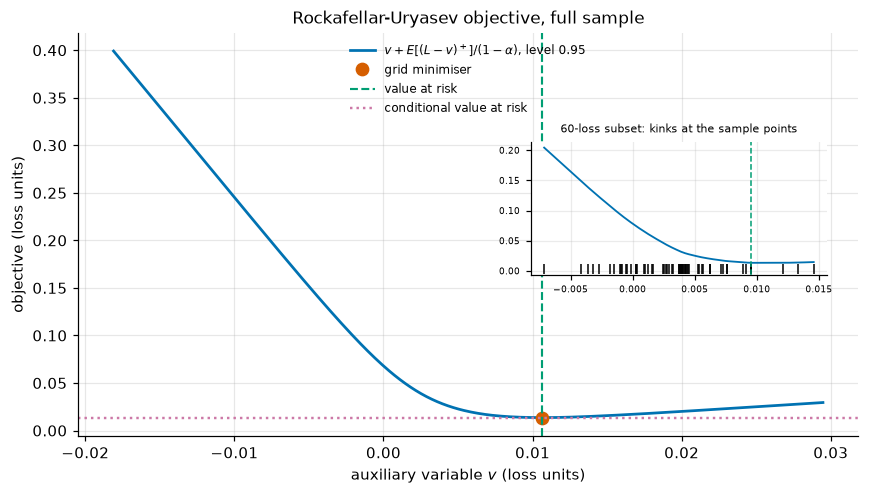

In [30]:
# Mid-research figure: the Rockafellar-Uryasev objective has its minimiser at the VaR and its minimum at the CVaR
vgrid = np.linspace(L6.min(), L6.max(), 400)
fv = np.array([ru_objective(float(v), L6, ALPHA6) for v in vgrid])
imin = int(np.argmin(fv))
print(f"grid minimiser {vgrid[imin]:.5f} versus value_at_risk {v6:.5f}; grid minimum {fv[imin]:.5f} versus cvar_tail_mean {c6:.5f}")
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(vgrid, fv, color=OKABE[0], lw=1.8, label="$v + E[(L-v)^+]/(1-\\alpha)$, level 0.95")
ax.plot(vgrid[imin], fv[imin], "o", color=OKABE[1], ms=8, label="grid minimiser")
ax.axvline(v6, color=OKABE[2], ls="--", lw=1.4, label="value at risk")
ax.axhline(c6, color=OKABE[3], ls=":", lw=1.6, label="conditional value at risk")
ax.set_xlabel("auxiliary variable $v$ (loss units)"); ax.set_ylabel("objective (loss units)")
ax.set_title("Rockafellar-Uryasev objective, full sample"); ax.legend(loc="upper center", fontsize=8); ax.grid(alpha=0.3)
sub = L6[:60]; vs = np.linspace(sub.min(), sub.max(), 800)
ins = ax.inset_axes([0.58, 0.40, 0.38, 0.33])
ins.plot(vs, [ru_objective(float(v), sub, ALPHA6) for v in vs], color=OKABE[0], lw=1.2)
ins.plot(sub, np.full(sub.size, ins.get_ylim()[0]), "|", color=OKABE[6], ms=6)
ins.axvline(value_at_risk(sub, ALPHA6), color=OKABE[2], ls="--", lw=1)
ins.set_title("60-loss subset: kinks at the sample points", fontsize=7); ins.tick_params(labelsize=6)
fig.tight_layout()
plt.show()

**How to read.** The curve is the objective as a function of the auxiliary variable; its lowest point sits at the value at risk and its height there is the conditional value at risk. The curve is flat near the minimum, so the minimiser is well determined. The inset uses only sixty losses so that the kinks, which sit at the sample points, are visible; with the full sample they are too small to see.

In [31]:
# RISK-1: Rockafellar-Uryasev against the sorted tail mean (n = 1001 is not a multiple of 1/(1-alpha))
rng6 = np.random.default_rng(6102)
samples = {"exponential minus one": rng6.exponential(size=1001) - 1.0, "hedging loss": L6[:1001]}
e1 = e2 = e3 = 0.0
for nm, x in samples.items():
    for al in (0.0, 0.5, 0.9, 0.95, 0.999):
        tm = cvar_tail_mean(x, al)
        e1 = max(e1, abs(cvar_ru(x, al) - tm))
        e2 = max(e2, abs(ru_objective(value_at_risk(x, al), x, al) - tm))
        e3 = max(e3, abs(min(ru_objective(float(v), x, al) for v in x) - tm))
obs = max(e1, e2, e3)
CHECK("RISK-1 Rockafellar-Uryasev: cvar_ru, objective at VaR, minimum over sample points all equal the tail mean", obs <= 1e-9, obs, "<= 1e-9")

# RISK-2: axioms by random trials (200)
measures = {"entropic g=1": lambda x: entropic_risk(x, 1.0), "entropic g=10": lambda x: entropic_risk(x, 10.0),
            "CVaR95 of the loss": lambda x: cvar_tail_mean(-x, 0.95)}
rng = np.random.default_rng(6103)
mono = conv = -np.inf; cash = 0.0
for _ in range(200):
    X1 = 0.3 * rng.standard_normal(400); X2 = X1 - np.abs(0.2 * rng.standard_normal(400))
    lam = rng.uniform(); Z = lam * X1 + (1 - lam) * X2
    for f in measures.values():
        mono = max(mono, f(X1) - f(X2))
        conv = max(conv, f(Z) - lam * f(X1) - (1 - lam) * f(X2))
        for c in (-1.0, 0.3, 2.0):
            cash = max(cash, abs(f(X1 + c) - (f(X1) - c)))
CHECK("RISK-2a monotone: max over trials of rho(X1) - rho(X2) for X1 >= X2", mono <= 1e-12, mono, "<= 1e-12")
CHECK("RISK-2b convexity: max over trials of rho(mix) - mix of rho", conv <= 1e-12, conv, "<= 1e-12")
CHECK("RISK-2c cash invariance rho(X + c) = rho(X) - c for c in {-1, 0.3, 2}", cash <= 1e-10, cash, "<= 1e-10")
X0 = 0.3 * rng.standard_normal(400)
print("INFO homogeneity ratio rho(3X)/rho(X):", {k: round(float(f(3 * X0) / f(X0)), 4) for k, f in measures.items()})

# RISK-3: Gaussian closed forms with standard errors from Derivation 3
nn = 400000; zz = np.random.default_rng(6104).standard_normal(nn)
vq = value_at_risk(zz, 0.95); summ = vq + np.maximum(zz - vq, 0.0) / 0.05
se_c = float(summ.std(ddof=1) / np.sqrt(nn)); tgt = float(norm.pdf(norm.ppf(0.95)) / 0.05)
zc = abs(cvar_tail_mean(zz, 0.95) - tgt) / se_c
CHECK("RISK-3a CVaR95 of N(0,1) draws against phi(Phi^-1(alpha))/(1-alpha), z", zc <= 4, zc, "z <= 4")
xg = 0.1 + 0.5 * np.random.default_rng(6105).standard_normal(nn); Wg = np.exp(-2.0 * xg)
se_e = float(Wg.std(ddof=1) / (2.0 * Wg.mean() * np.sqrt(nn)))
ze = abs(entropic_risk(xg, 2.0) - (-0.1 + 2.0 * 0.25 / 2)) / se_e
CHECK("RISK-3b entropic risk of N(0.1, 0.25) draws with gamma 2 against -mu + gamma s^2/2, z", ze <= 4, ze, "z <= 4")
print(f"INFO standard error of CVaR95 over standard error of the mean, same N(0,1) sample: {se_c / (zz.std(ddof=1) / np.sqrt(nn)):.3f}")

# RISK-4: gradients; n = 2003 so that the boundary weight is fractional
x4 = L6[:2003]; n4 = x4.size; a4 = 0.95
k4 = int(np.ceil(n4 * a4)); order = np.argsort(x4, kind="stable")
ws = np.zeros(n4); ws[k4:] = 1 / (n4 * (1 - a4)); ws[k4 - 1] = (k4 - n4 * a4) / (n4 * (1 - a4))
w4 = np.empty(n4); w4[order] = ws
coords = np.concatenate([np.random.default_rng(6106).choice(n4, 40, replace=False), order[k4 - 2:k4 + 1]])
eps = 1e-6; gerr = 0.0; eerr = 0.0
sm = np.exp(-10.0 * (-x4) - np.max(-10.0 * (-x4))); sm = sm / sm.sum()                # softmax(-gamma pnl), pnl = -x4
for j in coords:
    e = np.zeros(n4); e[j] = eps
    gerr = max(gerr, abs((cvar_tail_mean(x4 + e, a4) - cvar_tail_mean(x4 - e, a4)) / (2 * eps) - w4[j]))
    eerr = max(eerr, abs((entropic_risk(-x4 + e, 10.0) - entropic_risk(-x4 - e, 10.0)) / (2 * eps) - (-sm[j])))
CHECK("RISK-4a CVaR95 finite-difference gradient equals the interval-overlap weights (46 coordinates)", gerr <= 1e-7, gerr, "<= 1e-7")
CHECK("RISK-4b entropic finite-difference gradient (w.r.t. P&L) equals -softmax(-gamma x)", eerr <= 1e-7, eerr, "<= 1e-7")
CHECK("RISK-4c weights sum to one", abs(w4.sum() - 1) <= 1e-12, abs(w4.sum() - 1), "<= 1e-12")
try:
    import torch
    tt = torch.tensor(x4, dtype=torch.float64, requires_grad=True)
    cvar_tail_mean(tt, a4).backward()
    print("INFO torch autograd: max |gradient - weights| =", float(np.abs(tt.grad.numpy() - w4).max()))
except Exception as exc:
    print("INFO torch autograd comparison skipped:", type(exc).__name__)

CHECK RISK-1 Rockafellar-Uryasev: cvar_ru, objective at VaR, minimum over sample points all equal the tail mean | observed=4.707e-14 | expected=<= 1e-9 | PASS


CHECK RISK-2a monotone: max over trials of rho(X1) - rho(X2) for X1 >= X2 | observed=-0.0892 | expected=<= 1e-12 | PASS
CHECK RISK-2b convexity: max over trials of rho(mix) - mix of rho | observed=-1.972e-05 | expected=<= 1e-12 | PASS
CHECK RISK-2c cash invariance rho(X + c) = rho(X) - c for c in {-1, 0.3, 2} | observed=1.066e-14 | expected=<= 1e-10 | PASS
INFO homogeneity ratio rho(3X)/rho(X): {'entropic g=1': 13.288, 'entropic g=10': 5.5168, 'CVaR95 of the loss': 3.0}
CHECK RISK-3a CVaR95 of N(0,1) draws against phi(Phi^-1(alpha))/(1-alpha), z | observed=2.15 | expected=z <= 4 | PASS
CHECK RISK-3b entropic risk of N(0.1, 0.25) draws with gamma 2 against -mu + gamma s^2/2, z | observed=1.468 | expected=z <= 4 | PASS
INFO standard error of CVaR95 over standard error of the mean, same N(0,1) sample: 2.440
CHECK RISK-4a CVaR95 finite-difference gradient equals the interval-overlap weights (46 coordinates) | observed=7.009e-13 | expected=<= 1e-7 | PASS
CHECK RISK-4b entropic finite-differ

INFO torch autograd: max |gradient - weights| = 1.5942108744226857e-15


                       max |cvar_ru - oracle|  max |cvar_tail_mean - oracle|
exponential minus one            6.474821e-13                   6.270540e-13
hedging loss                     2.341877e-15                   2.321060e-15


        CVaR95  entropic g=10  entropic g=100
delta  0.01364        0.00286         0.00387
band   0.02042        0.00183         0.00602
OBSERVED lowest risk by CVaR95: delta
OBSERVED lowest risk by entropic g=10: band
OBSERVED lowest risk by entropic g=100: delta


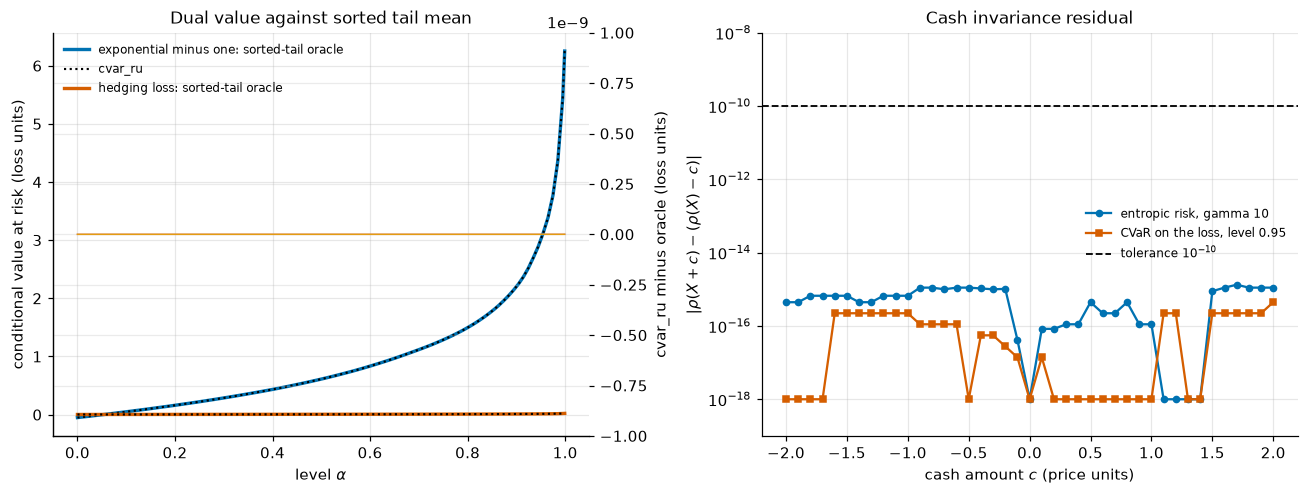

In [32]:
# Post-research figure: dual value against the sorted-tail oracle, and cash invariance
rngp = np.random.default_rng(6107)
smp = {"exponential minus one": rngp.exponential(size=1001) - 1.0, "hedging loss": L6[:1001]}
als = np.concatenate([np.linspace(0.0, 0.995, 100), [0.999]])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax2 = ax[0].twinx(); gap = {}
for k, (nm, x) in enumerate(smp.items()):
    srt = np.sort(x); lo = np.arange(srt.size) / srt.size
    orc = np.array([np.clip(lo + 1 / srt.size - np.maximum(lo, a), 0, None) @ srt / (1 - a) for a in als])    # overlap-weight oracle
    ru = np.array([cvar_ru(x, a) for a in als]); tm = np.array([cvar_tail_mean(x, a) for a in als])
    gap[nm] = (float(np.abs(ru - orc).max()), float(np.abs(tm - orc).max()))
    ax[0].plot(als, orc, color=OKABE[k], lw=2.2, label=f"{nm}: sorted-tail oracle")
    ax[0].plot(als, ru, color=OKABE[6], ls=":", lw=1.4, label="cvar_ru" if k == 0 else None)
    ax2.plot(als, ru - orc, color=OKABE[k + 3], lw=1, alpha=0.9)
ax2.set_ylim(-1e-9, 1e-9); ax2.set_ylabel("cvar_ru minus oracle (loss units)")
ax[0].set_xlabel("level $\\alpha$"); ax[0].set_ylabel("conditional value at risk (loss units)")
ax[0].set_title("Dual value against sorted tail mean"); ax[0].legend(fontsize=8, loc="upper left"); ax[0].grid(alpha=0.3)
print(pd.DataFrame(gap, index=["max |cvar_ru - oracle|", "max |cvar_tail_mean - oracle|"]).T.to_string())
Xp = -L6[:1001]; cs = np.linspace(-2, 2, 41)
r_e = [abs(entropic_risk(Xp + c, 10.0) - (entropic_risk(Xp, 10.0) - c)) for c in cs]
r_c = [abs(cvar_tail_mean(-(Xp + c), 0.95) - (cvar_tail_mean(-Xp, 0.95) - c)) for c in cs]
ax[1].plot(cs, np.maximum(r_e, 1e-18), "o-", color=OKABE[0], ms=4, label="entropic risk, gamma 10")
ax[1].plot(cs, np.maximum(r_c, 1e-18), "s-", color=OKABE[1], ms=4, label="CVaR on the loss, level 0.95")
ax[1].axhline(1e-10, color=OKABE[6], ls="--", lw=1.2, label="tolerance $10^{-10}$")
ax[1].set_yscale("log"); ax[1].set_ylim(1e-19, 1e-8)
ax[1].set_xlabel("cash amount $c$ (price units)"); ax[1].set_ylabel("$|\\rho(X+c)-(\\rho(X)-c)|$")
ax[1].set_title("Cash invariance residual"); ax[1].legend(fontsize=8, loc="center right"); ax[1].grid(alpha=0.3)
fig.tight_layout()
# strategy comparison on the same paths, cost 10 bp
bnd = run_strategy(S6, ww_policy(K6, SIG6, T6, N6, COST6, 10.0), K6, COST6, p0=P6)
rows = {}
for nm, r in (("delta", res6), ("band", bnd)):
    rows[nm] = [cvar_tail_mean(-r.pnl, 0.95), entropic_risk(r.pnl, 10.0), entropic_risk(r.pnl, 100.0)]
cmp6 = pd.DataFrame(rows, index=["CVaR95", "entropic g=10", "entropic g=100"]).T
print(cmp6.round(5).to_string())
for col in cmp6.columns:
    print(f"OBSERVED lowest risk by {col}:", cmp6[col].idxmin())
plt.show()

**How to read.** The first panel compares two independent computations of the same tail average at every level, for two samples whose size is not a multiple of one over the tail mass; the second axis shows their difference on a scale of one part in a billion. The second panel shows what adding cash does to each risk measure, which should be exactly a shift: the residual stays at rounding level, and points on the floor of the log axis are exact.

**Interpretation.** The objective is convex and piecewise linear, flat near its minimiser, so the auxiliary variable is easy to learn jointly with the hedge, and its kinks sit only at sample points, hence the almost-everywhere differentiability of Derivation 2. The conditional value at risk lies above the value at risk and the mean. Cash invariance means that adding the premium shifts the risk one-for-one and leaves gradients unchanged. The entropic measure is smooth and uses the whole distribution, the conditional value at risk only the tail, and homogeneity separates them: scaling a position scales the conditional value at risk exactly, but not the entropic risk.

*Negative result.* The conditional value at risk estimator is noisier than the sample mean at the same sample size: the printed ratio of standard errors is above one. The last table ranks the delta and band strategies by each measure on the same paths; read only the ranking that prints, and note that the measures need not agree.

**Limits.** No trace states the Rockafellar-Uryasev theorem (rhB-q12 Part 2 only calls it derivable), so Derivation 1 is the notebook's own proof. Buehler's Eq 5.1 names the level by the tail mass, the package by the quantile level (a naming difference only). Buehler et al. report realised tail risk at two levels from single runs with no uncertainty (rhB-q12 Part 1, rhB-q7 Sec 3 (c)); rhB-q4 reports the conditional value at risk at level $0.95$ as a secondary metric under an entropic training loss on a Black-Scholes market only (rhB-q4 Sec 4, Sec 5). No trace gives a convergence rate for training with the Rockafellar-Uryasev loss, nor a rough-volatility result with proportional costs and a tail measure (rhB-q2 Sec 4, rhB-q12 Part 2). The risk aversion of the band and the entropic parameters used here are not tuned; the strategy ranking is for one simulated sample.